[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab5-Comp-Mod/notebooks/07-dce-mri-kidney-explore.ipynb)

# 07 — DCE-MRI of the Kidney: Computational Imaging and Modeling for GFR Estimation

**BMED365 – Computational Medicine (Lab 5)**

_Arvid Lundervold w/ Claude (Anthropic) — 2026-02-15_<br>
_Based on: [01-dce-mri-kidney-explore.ipynb](https://github.com/computational-medicine/BMED360-2021/blob/main/Lab5-DCE-MRI/01-dce-mri-kidney-explore.ipynb) (BMED360-2021) and [functional-kidney-imaging](https://github.com/arvidl/functional-kidney-imaging) (ESMRMB 2016)_<br>
_Updated: 2026-02-19_  (Cursor 2.5.17 with Claude Opus 4.6) <br>
_Updated: 2026-02-20_  (Cursor 2.5.20 with Claude Opus 4.6) - saved notebook to .pdf<br>
_Updated: 2026-02-28_  (Ubuntu 24.04, Cursor 2.5.26 with Claude Opus 4.6) - Testing

---

> **Prerequisites**: You should have worked through [06-kidney-filtration.ipynb](./06-kidney-filtration.ipynb), which introduces the physiology of glomerular filtration and the concept of GFR. This notebook extends that foundation into the realm of **medical imaging** — specifically **Dynamic Contrast-Enhanced MRI (DCE-MRI)** — to explore how GFR can be estimated non-invasively from image data.

## 1. Motivation & Learning Objectives

### Why image-based GFR estimation?

In [notebook 06](./06-kidney-filtration.ipynb), we saw that **Glomerular Filtration Rate (GFR)** is the single most important measure of kidney function. Traditionally, GFR is measured using blood and urine tests (inulin clearance, creatinine clearance) or estimated from serum creatinine using equations (CKD-EPI). However, these methods provide only a **global** (whole-body) estimate — they cannot tell us:

- **Which kidney** is functioning better (critical for surgical planning)
- **Where** within a kidney the function is impaired (focal vs. diffuse disease)
- **How** kidney function changes dynamically over seconds to minutes

**Dynamic Contrast-Enhanced MRI (DCE-MRI)** addresses all these limitations by:

1. **Imaging both kidneys simultaneously** with high spatial resolution
2. **Tracking** the passage of a gadolinium-based contrast agent (GBCA) through the renal vasculature and tubules over time
3. **Applying tracer kinetic models** (compartment models) to the time-varying signal to estimate physiological parameters — including **single-kidney GFR** (skGFR)

This makes DCE-MRI a powerful tool in computational medicine: it combines **physics** (MRI signal formation), **physiology** (renal hemodynamics), **mathematics** (tracer kinetics, ODEs), and **computation** (curve fitting, motion correction, clustering) into a single quantitative pipeline.

### Clinical need

- **Chronic Kidney Disease (CKD)** affects >800 million people globally (~10–15% of adults)
- **Living kidney donation** requires accurate assessment of individual kidney function
- **Renal artery stenosis**, **hydronephrosis**, and **renal tumors** can cause asymmetric kidney damage
- **Pediatric nephrology** needs radiation-free methods (unlike nuclear medicine)
- Standard eGFR equations have limited accuracy in extremes of body composition, age, and diet

### What you will learn

In this notebook you will:

1. **Understand** what DCE-MRI is and how it measures kidney function
2. **Explore** real 4D (3D + time) DCE-MRI data of the kidney
3. **Appreciate** the challenges of **motion correction** in abdominal DCE-MRI
4. **Apply K-means clustering** to segment kidney tissue based on signal intensity time courses ($\mathbf{R}^{50}$ feature space)
5. **Use K-means "smoothing"** to create prototypic time courses that reduce noise
6. **Implement tracer kinetic models** (compartment models) to estimate renal perfusion and GFR
7. **Understand** the historical development and clinical translation of DCE-MRI-based GFR estimation

## 2. What is DCE-MRI? — Definitions and Key Concepts

### 2.1 Dynamic Contrast-Enhanced MRI (DCE-MRI)

**DCE-MRI** is an MRI technique where:
1. A **gadolinium-based contrast agent (GBCA)** is injected intravenously as a bolus
2. Rapid, repeated MRI acquisitions (typically every 2–5 seconds) capture the **time-varying signal** as the contrast agent passes through the tissue
3. The resulting **4D dataset** (3D spatial + time) encodes information about tissue perfusion, permeability, and filtration

| Term | Definition |
|------|------------|
| **GBCA** | Gadolinium-Based Contrast Agent — a paramagnetic substance that shortens T₁ relaxation time, causing signal enhancement on T₁-weighted images |
| **Bolus** | A single, rapid injection of contrast agent (typically 0.05–0.1 mmol/kg body weight) |
| **Temporal resolution** | Time between successive 3D volume acquisitions (Δt ≈ 2–5 s for renal DCE-MRI) |
| **Signal intensity time course** | S(t) — the MRI signal measured in a voxel or region as a function of time |
| **Concentration time course** | C(t) — the contrast agent concentration derived from S(t) using a signal model |
| **Arterial Input Function (AIF)** | $C_a(t)$ — the concentration time course in a feeding artery (e.g., aorta or renal artery) |

### 2.2 From Signal to Concentration

The MRI signal in a T₁-weighted spoiled gradient echo (SPGR) sequence depends on the longitudinal relaxation rate $R_1 = 1/T_1$:

$$S(t) = S_0 \cdot \frac{\sin\alpha \cdot (1 - e^{-TR \cdot R_1(t)})}{1 - \cos\alpha \cdot e^{-TR \cdot R_1(t)}}$$

where $\alpha$ is the flip angle and $TR$ is the repetition time. The contrast agent increases $R_1$ linearly:

$$R_1(t) = R_{1,0} + r_1 \cdot C(t)$$

where $R_{1,0}$ is the baseline (pre-contrast) relaxation rate and $r_1$ is the **relaxivity** of the contrast agent (≈ 3.7–4.5 L·mmol⁻¹·s⁻¹ at 1.5 T for typical GBCAs).

### 2.3 Tracer Kinetics and Compartment Models

A **compartment model** represents the tissue as a set of well-mixed compartments connected by rate constants. For the kidney, the key compartments are:

| Compartment | Physical meaning | Symbol |
|-------------|-----------------|--------|
| **Vascular (plasma)** | Blood plasma in glomerular and peritubular capillaries | $v_p$ (fractional volume) |
| **Tubular** | Fluid in proximal tubules (after filtration) | $v_t$ (fractional volume) |
| **Interstitial** | Extracellular, extravascular space | $v_e$ (fractional volume) |

The **two-compartment filtration model** for the kidney (Sourbron et al., 2008; Annet et al., 2004) describes contrast agent transport as:

$$C_{tissue}(t) = v_p \cdot C_a(t) + GFR \cdot \int_0^t C_a(\tau) \, d\tau - k_{out} \cdot \int_0^t C_{tissue}(\tau) \, d\tau$$

where:
- $v_p$ = plasma volume fraction  
- $GFR$ = glomerular filtration rate (per unit tissue volume, mL/min/mL)
- $k_{out}$ = tubular outflow rate constant (related to transit time through the tubules)

### 2.4 Glomerular Filtration Rate (GFR) from DCE-MRI

The **single-kidney GFR** (skGFR) is obtained by:

$$\text{skGFR} = GFR_{density} \times V_{kidney}$$

where $GFR_{density}$ is the filtration rate per unit volume of functioning parenchyma and $V_{kidney}$ is the kidney volume (measured from the MRI images).

**Reference values:**
- Total GFR (both kidneys): ~90–120 mL/min (age- and sex-dependent)
- Single-kidney GFR: ~45–60 mL/min (assuming symmetric function)

### 2.5 The Measurement Pipeline

The complete DCE-MRI pipeline for kidney GFR estimation involves:

```
MRI Acquisition  →  Motion Correction  →  Signal-to-Concentration  →  AIF Extraction
                                                                          ↓
    GFR Map  ←  Compartment Model Fitting  ←  ROI / Voxel-wise Analysis  ←
```

Each step introduces potential errors and requires careful computational methods.

In [1]:
# --- Colab setup ---
import sys
if 'google.colab' in sys.modules:
    %pip install -q nibabel gdown
    import urllib.request, os
    os.makedirs('../assets', exist_ok=True)
    _base = 'https://raw.githubusercontent.com/arvidl/BMED365-2026/main/Lab5-Comp-Mod/assets/'
    for f in ['BMED_360_Lec6_vascular_permeability_dce_mri_kidney_volme_time_series_capio_2005.png',
              'BMED_360_Lec6_vascular_permeability_dce_mri_mass_balance_kidney_filtration.png',
              'BMED_360_Lec6_vascular_permeability_dce_mri_model_based_analysis.png',
              'BMED_360_Lec6_vascular_permeability_dce_mri_pharmacokinetic_model.png']:
        if not os.path.exists(f'../assets/{f}'):
            urllib.request.urlretrieve(_base + f, f'../assets/{f}')

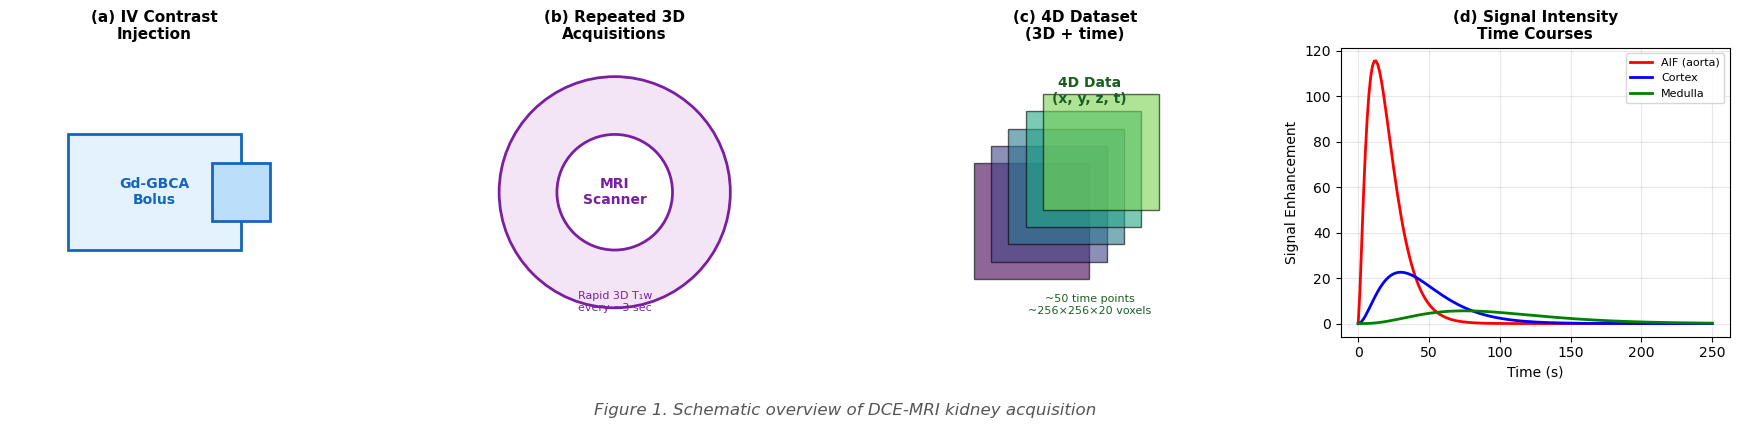

In [2]:
from IPython.display import HTML, display, Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch, Ellipse
import numpy as np
from scipy.stats import gamma as gamma_dist

# ──────────────────────────────────────────────────
# Figure: Schematic of DCE-MRI acquisition pipeline
# ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Panel 1: Contrast injection
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.add_patch(plt.Rectangle((2, 3), 6, 4, fill=True, facecolor='#e3f2fd', edgecolor='#1565c0', lw=2))
ax.add_patch(plt.Rectangle((7, 4), 2, 2, fill=True, facecolor='#bbdefb', edgecolor='#1565c0', lw=2))
ax.text(5, 5, 'Gd-GBCA\nBolus', ha='center', va='center', fontsize=10, fontweight='bold', color='#1565c0')
ax.set_title('(a) IV Contrast\nInjection', fontsize=11, fontweight='bold')
ax.axis('off')

# Panel 2: MRI scanner
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.set_aspect('equal')
ax.add_patch(Ellipse((5, 5), 8, 8, fill=True, facecolor='#f3e5f5', edgecolor='#7b1fa2', lw=2))
ax.add_patch(Ellipse((5, 5), 4, 4, fill=True, facecolor='white', edgecolor='#7b1fa2', lw=2))
ax.text(5, 5, 'MRI\nScanner', ha='center', va='center', fontsize=10, fontweight='bold', color='#7b1fa2')
ax.text(5, 1.2, 'Rapid 3D T\u2081w\nevery ~3 sec', ha='center', va='center', fontsize=8, color='#7b1fa2')
ax.set_title('(b) Repeated 3D\nAcquisitions', fontsize=11, fontweight='bold')
ax.axis('off')

# Panel 3: 4D data cube
ax = axes[2]
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.set_aspect('equal')
for i in range(5):
    offset = i * 0.6
    c = plt.cm.viridis(i/5)
    ax.add_patch(plt.Rectangle((1.5+offset, 2+offset), 4, 4, fill=True,
                                facecolor=c, edgecolor='black', lw=1, alpha=0.6))
ax.text(5.5, 8.5, '4D Data\n(x, y, z, t)', ha='center', va='center',
        fontsize=10, fontweight='bold', color='#1b5e20')
ax.text(5.5, 0.8, '~50 time points\n~256\u00d7256\u00d720 voxels', ha='center', fontsize=8, color='#1b5e20')
ax.set_title('(c) 4D Dataset\n(3D + time)', fontsize=11, fontweight='bold')
ax.axis('off')

# Panel 4: Time course
ax = axes[3]
t = np.linspace(0, 250, 200)
cortex = 5.0 * gamma_dist.pdf(t, a=3, scale=15) * 250
medulla = 2.5 * gamma_dist.pdf(t, a=4, scale=25) * 250
aif = 12.0 * gamma_dist.pdf(t, a=2.5, scale=8) * 250
ax.plot(t, aif, 'r-', lw=2, label='AIF (aorta)')
ax.plot(t, cortex, 'b-', lw=2, label='Cortex')
ax.plot(t, medulla, 'g-', lw=2, label='Medulla')
ax.set_xlabel('Time (s)', fontsize=10)
ax.set_ylabel('Signal Enhancement', fontsize=10)
ax.set_title('(d) Signal Intensity\nTime Courses', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Figure 1. Schematic overview of DCE-MRI kidney acquisition', y=-0.02,
             fontsize=12, fontstyle='italic', color='#555')
plt.show()

## 3. Historical Context

### The road to DCE-MRI-based GFR estimation

The idea of using dynamic imaging with exogenous tracers to quantify organ function has a rich history spanning nuclear medicine, CT, and MRI.

| Year | Milestone | Key Contributors |
|------|-----------|----------------:|
| 1927 | **Indicator dilution theory** — mathematical framework for tracer kinetics | Hamilton, Moore, Kinsman |
| 1954 | **Renography** — first dynamic nuclear imaging of the kidneys using ¹³¹I-hippuran | Taplin, Meredith, Kade, Winter |
| 1960s | **Compartment modeling** formalized for pharmacokinetics | Teorell, Rescigno, Segre |
| 1984 | **First DCE-MRI** studies using Gd-DTPA in brain tumors | Weinmann, Brasch, Runge |
| 1991 | **Tofts model** — standard pharmacokinetic model for DCE-MRI | Paul **Tofts** & Allan **Kermode** |
| 1994 | First DCE-MRI of the kidneys with Gd-DTPA for renal function assessment | Prigent, Cosgriff, Gates |
| 1999 | **Extended Tofts model** including vascular term $v_p$ | Paul **Tofts** et al. |
| 2004 | **Annet model** — two-compartment (vascular + tubular) model for renal DCE-MRI | Laurent **Annet** et al. |
| 2008 | **Sourbron separable compartment model** for renal perfusion and filtration | Steven **Sourbron** et al. |
| 2012 | ISMRM Perfusion Study Group consensus on DCE-MRI nomenclature | Tofts, Sourbron, Buckley et al. |
| 2014 | **Hodneland et al.** — segmentation-driven image registration for kidney DCE-MRI motion correction | Erlend **Hodneland** et al. |
| 2015 | **Eikefjord et al.** — comprehensive framework for DCE-MRI GFR estimation at 1.5T | Eli **Eikefjord** et al. |
| 2018 | PARENCHIMA COST Action — European consortium for standardization of renal MRI | Nils **Grenier**, Steven **Sourbron** et al. |
| 2020 | Consensus paper on technical recommendations for clinical renal MRI | Mendichovszky, Notohamiprodjo et al. |
| 2023–26 | AI/ML approaches for automated DCE-MRI analysis, AIF detection, motion correction | Multiple groups |

### Paul Tofts and the pharmacokinetic model

**Paul S. Tofts** (b. 1947) at University College London developed the most widely used pharmacokinetic model for DCE-MRI analysis. His 1991 paper with Kermode established the framework for quantitative analysis of blood-brain barrier permeability from DCE-MRI. The **Tofts model** and its extensions remain the foundation of DCE-MRI analysis across organs.

### From brain to kidney: the challenges

While DCE-MRI was first developed for brain tumors, applying it to the **kidneys** introduced unique challenges:

1. **Respiratory motion** — the kidneys move 1–3 cm with each breath, requiring motion correction or breath-hold protocols
2. **Complex anatomy** — cortex and medulla have very different enhancement patterns
3. **Filtration** — unlike most tissues where contrast leaks passively, the kidney actively **filters** contrast through the glomeruli
4. **Rapid dynamics** — renal enhancement peaks within 15–30 seconds, requiring high temporal resolution

### Bergen contributions

The University of Bergen group (Lundervold, Eikefjord, Hodneland, Rørvik, Svarstad) has made significant contributions to renal DCE-MRI:

- **Segmentation-driven motion correction** (Hodneland et al., IEEE TIP 2014)
- **Comprehensive GFR estimation framework** comparing FLASH and KWIC acquisitions (Eikefjord et al., AJR 2015)
- **Repeatability, accuracy, and precision** of DCE-MRI GFR using iohexol-GFR as reference (Eikefjord et al., Acta Radiol 2017)

In [3]:
# Display an illustrative image of kidney anatomy relevant to DCE-MRI
# Try multiple sources for robustness
from IPython.display import HTML, display
import urllib.request

# Primary: Holly Fischer kidney cross section (CC BY 3.0, University of Michigan)
img_url = "https://upload.wikimedia.org/wikipedia/commons/0/01/Kidney_Cross_Section.png"
# Fallback: original PioM image (full resolution, not thumbnail)
img_url_fallback = "https://upload.wikimedia.org/wikipedia/commons/7/7e/Kidney_PioM.png"

# Test which URL is reachable
url_to_use = img_url
try:
    req = urllib.request.Request(img_url, headers={'User-Agent': 'Mozilla/5.0'})
    urllib.request.urlopen(req, timeout=5)
except Exception:
    try:
        req = urllib.request.Request(img_url_fallback, headers={'User-Agent': 'Mozilla/5.0'})
        urllib.request.urlopen(req, timeout=5)
        url_to_use = img_url_fallback
    except Exception:
        url_to_use = img_url  # use primary anyway, browser might succeed

display(HTML(f"""
<figure style="text-align:center; margin: 20px 0;">
<img src="{url_to_use}"
     alt="Kidney anatomy cross-section" width="450"
     onerror="this.onerror=null; this.src='{img_url_fallback}';" />
<figcaption style="font-size:0.9em; color:#555; margin-top:8px;">
<b>Figure 2.</b> Cross-section of the human kidney. In DCE-MRI, the contrast agent enters via the
<b>renal artery</b>, passes through the cortical <b>glomeruli</b> (where it is filtered), and transits
through the <b>medullary</b> tubules before being excreted via the <b>collecting system</b>.
The cortex enhances rapidly (high perfusion), while the medulla enhances more slowly (tubular transit).
<br/><i>Source: Wikimedia Commons (Holly Fischer / Piotr Micha&#322; Jaworski, CC BY 3.0 / CC BY-SA 3.0).</i>
</figcaption>
</figure>
"""))

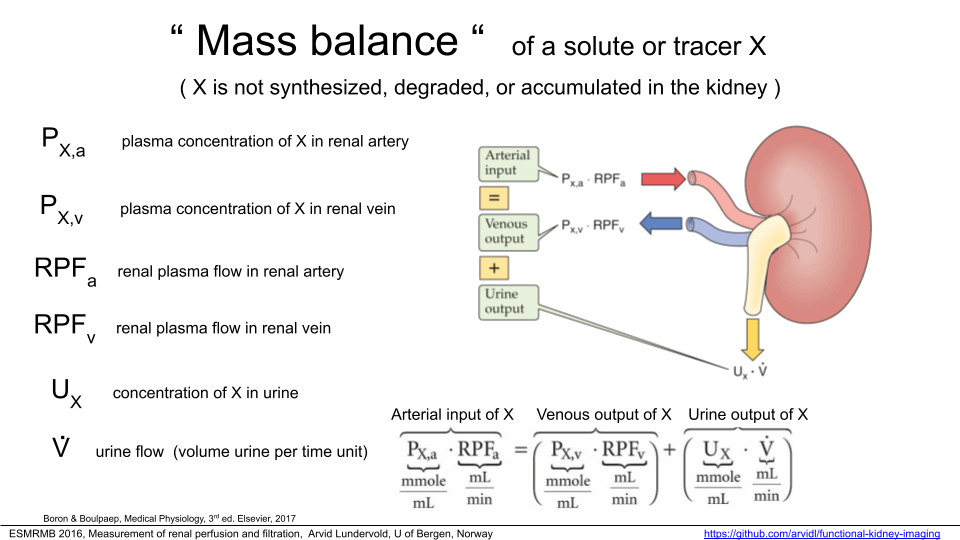

In [4]:
# Illustration: Mass balance and kidney filtration in DCE-MRI
# Source: BMED360 Lecture 6 (Lundervold, University of Bergen)
from IPython.display import Image, display, HTML

display(Image('../assets/BMED_360_Lec6_vascular_permeability_dce_mri_mass_balance_kidney_filtration.png', width=800))
display(HTML("""
<figcaption style="font-size:0.9em; color:#555; margin-top:4px; text-align:center;">
<b>Figure.</b> <b>Mass balance and kidney filtration</b> in the context of DCE-MRI.
The principle of <i>conservation of mass</i> (indicator dilution theory) underlies the
tracer kinetic models used to estimate GFR from DCE-MRI. The contrast agent concentration
in tissue reflects the balance between arterial inflow, glomerular filtration into the
tubules, and venous/urinary outflow.
<br/><i>Source: BMED360 Lecture 6 &mdash; Vascular permeability and DCE-MRI (A. Lundervold, UiB).</i>
</figcaption>
"""))

## 4. Scientific and Clinical Implications

### Why DCE-MRI matters for kidney disease

| Clinical scenario | Limitation of eGFR | DCE-MRI advantage |
|---|---|---|
| **Kidney donor evaluation** | Cannot assess individual kidney function | Provides **single-kidney GFR** |
| **Renal artery stenosis** | May be falsely normal if one kidney compensates | Shows **asymmetric** function loss |
| **Partial nephrectomy planning** | Cannot predict remaining function after surgery | Maps **regional** function |
| **Pediatric CKD** | eGFR equations less reliable in children | **Radiation-free**, accurate, repeatable |
| **Transplant monitoring** | Slow creatinine response to acute rejection | **Real-time** perfusion changes |
| **Drug nephrotoxicity** | Serum creatinine rises only after significant damage | May detect **early** functional changes |

### The computational medicine perspective

DCE-MRI-based GFR estimation is a prime example of **computational medicine** in action:

1. **Physics** → MRI signal formation (Bloch equations, relaxation, contrast agent relaxivity)
2. **Engineering** → Fast pulse sequences (FLASH, KWIC, radial), parallel imaging, motion correction
3. **Mathematics** → Tracer kinetics (convolution integrals, ODEs), compartment models, curve fitting
4. **Computer science** → Image registration, K-means clustering, optimization algorithms, machine learning
5. **Physiology** → Renal hemodynamics, glomerular filtration, tubular function
6. **Clinical medicine** → Diagnosis, treatment planning, monitoring

This notebook sits at the intersection of all these disciplines — exactly what computational medicine is about.

### Check Your Understanding: Motivation and Concepts

**Q1.** What key limitation of serum creatinine-based eGFR does DCE-MRI overcome?

<details>
<summary>Click to reveal answer</summary>

eGFR provides only a **global** (total, both-kidneys) estimate of GFR. It cannot distinguish between the function of the left and right kidneys. DCE-MRI provides **single-kidney GFR** and can even map **regional** variations in function within a single kidney. This is critical for kidney donor evaluation, surgical planning (partial nephrectomy), and detecting asymmetric disease (e.g., unilateral renal artery stenosis).

</details>

**Q2.** Name the three main tissue compartments in a kidney DCE-MRI compartment model and explain what each represents.

<details>
<summary>Click to reveal answer</summary>

1. **Vascular (plasma) compartment** ($v_p$): Blood plasma within the glomerular and peritubular capillaries. Contrast arrives here first via the renal artery.
2. **Tubular compartment** ($v_t$): Fluid within the proximal tubules, loop of Henle, and distal tubules. Contrast enters this compartment by **glomerular filtration** (this is what we want to measure!).
3. **Interstitial compartment** ($v_e$): Extracellular, extravascular space in the renal parenchyma. Some contrast may leak here from peritubular capillaries.

The rate constant from plasma to tubular compartment is directly related to **GFR**.

</details>

**Q3.** Why is motion correction particularly important in kidney DCE-MRI compared to brain DCE-MRI?

<details>
<summary>Click to reveal answer</summary>

The kidneys are located in the abdomen and move significantly due to **respiratory motion** (1–3 cm craniocaudal displacement per breath cycle). The brain, protected by the rigid skull, has essentially no respiratory motion. Without motion correction, signal intensity time courses in kidney DCE-MRI would sample different tissue voxels at different time points, making the curves unreliable for quantitative analysis. Motion correction is therefore a **critical preprocessing step** for accurate GFR estimation from kidney DCE-MRI.

</details>

## 5. Setup and Data

### Required packages

This notebook uses standard scientific Python packages plus `nibabel` for neuroimaging file I/O, `scikit-learn` for K-means clustering, and `gdown` for downloading data from Google Drive.

### The DCE-MRI dataset

We use a **4D NIfTI** file from a clinical DCE-MRI kidney examination:
- **Patient**: Anonymized subject from a renal function study
- **Scanner**: 1.5T MRI (Siemens)
- **Sequence**: 3D T₁-weighted spoiled gradient echo (FLASH)
- **Contrast agent**: Gd-DTPA (Magnevist), 0.05 mmol/kg
- **Temporal resolution**: ~3 seconds per 3D volume
- **Dimensions**: 256 × 256 × 20 slices × ~50 time points (= ~65 million voxels total)
- **File**: `kidney_capio_20050419_series_13_32.nii.gz`

In [5]:
%matplotlib inline
import os
from os.path import expanduser, join, basename, split
import pathlib
import shutil
import platform
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Ellipse
from mpl_toolkits.axes_grid1 import make_axes_locatable
from IPython.display import HTML, display, Image

# Medical imaging / ML
import nibabel as nib
from sklearn.cluster import KMeans
from scipy.ndimage import gaussian_filter
from scipy.optimize import curve_fit
from scipy.stats import gamma as gamma_dist
from scipy.integrate import odeint

print('All imports successful')
print(f'  Platform: {platform.system()} ({platform.machine()})')
print(f'  NumPy:    {np.__version__}')
print(f'  nibabel:  {nib.__version__}')

All imports successful
  Platform: Linux (x86_64)
  NumPy:    2.0.2
  nibabel:  5.3.2


In [6]:
# Download DCE-MRI data from Google Drive using gdown
# Data and assets from BMED360-2021 Lab5-DCE-MRI

cwd = os.getcwd()
data_dir = join(cwd, 'data')
assets_dir = join(cwd, 'assets')

try:
    import gdown
except ImportError:
    %pip install -q gdown
    import gdown

# Download data.zip if ./data does not exist
if not os.path.isdir(data_dir):
    print('Downloading DCE-MRI data from Google Drive...')
    file_id = '13e8EqQF9xgdRdCCi-bB_BaYrkUCVs0sX'
    url = f'https://drive.google.com/uc?id={file_id}'
    output = './data.zip'
    gdown.download(url, output, quiet=False)
    shutil.unpack_archive(output, '.')
    os.remove(output)
    print('Data downloaded and extracted')
else:
    print(f'./data exists already!')

# Download assets.zip if ./assets does not exist
if not os.path.isdir(assets_dir):
    print('Downloading assets from Google Drive...')
    file_id = '1fM6fIG9fuxX28_pQtrZZLyRxZZTF01tG'
    url = f'https://drive.google.com/uc?id={file_id}'
    output = './assets.zip'
    gdown.download(url, output, quiet=False)
    shutil.unpack_archive(output, '.')
    os.remove(output)
    print('Assets downloaded and extracted')
else:
    print(f'./assets exists already!')

fn = f'{data_dir}/kidney_capio_20050419_series_13_32.nii.gz'
print(f'\nData file: {fn}')
print(f'File exists: {os.path.exists(fn)}')

Downloading...
From (original): https://drive.google.com/uc?id=13e8EqQF9xgdRdCCi-bB_BaYrkUCVs0sX
From (redirected): https://drive.google.com/uc?id=13e8EqQF9xgdRdCCi-bB_BaYrkUCVs0sX&confirm=t&uuid=a575fa84-ef60-4fe0-9414-69a7b6e04626
To: /home/arvid/GitHub/BMED365-2026/Lab5-Comp-Mod/notebooks/data.zip
100%|██████████| 263M/263M [00:07<00:00, 37.1MB/s] 


Data downloaded and extracted
./assets exists already!

Data file: /home/arvid/GitHub/BMED365-2026/Lab5-Comp-Mod/notebooks/data/kidney_capio_20050419_series_13_32.nii.gz
File exists: True


In [7]:
# Load the 4D DCE-MRI NIfTI file
img = nib.load(fn)
data = img.get_fdata()
hdr = img.header

print('=' * 60)
print('4D DCE-MRI Dataset Summary')
print('=' * 60)
print(f'  Shape:       {data.shape}')
print(f'  Dimensions:  {data.shape[0]}x{data.shape[1]} in-plane, '
      f'{data.shape[2]} slices, {data.shape[3]} time points')
print(f'  Voxel size:  {hdr.get_zooms()[:3]} mm')
if len(hdr.get_zooms()) > 3:
    print(f'  TR (approx): {hdr.get_zooms()[3]:.1f} s')
print(f'  Data type:   {data.dtype}')
print(f'  Value range: [{data.min():.1f}, {data.max():.1f}]')
print(f'  Memory:      {data.nbytes / 1e6:.1f} MB')

n_x, n_y, n_z, n_t = data.shape
print(f'\n  Total voxels per time point: {n_x * n_y * n_z:,}')
print(f'  Total voxel-time measurements: {data.size:,}')

4D DCE-MRI Dataset Summary
  Shape:       (256, 256, 20, 20)
  Dimensions:  256x256 in-plane, 20 slices, 20 time points
  Voxel size:  (np.float32(1.484375), np.float32(1.484375), np.float32(3.0)) mm
  TR (approx): 2.5 s
  Data type:   float64
  Value range: [0.0, 143.0]
  Memory:      209.7 MB

  Total voxels per time point: 1,310,720
  Total voxel-time measurements: 26,214,400


## 6. Exploring the 4D DCE-MRI Data

Let's visualize the DCE-MRI data to understand its structure. We'll look at:
1. **Anatomical view** — a single time point to see the kidney anatomy
2. **Temporal montage** — the same slice at different time points to see contrast dynamics
3. **Signal intensity time courses** — S(t) curves from different tissue types

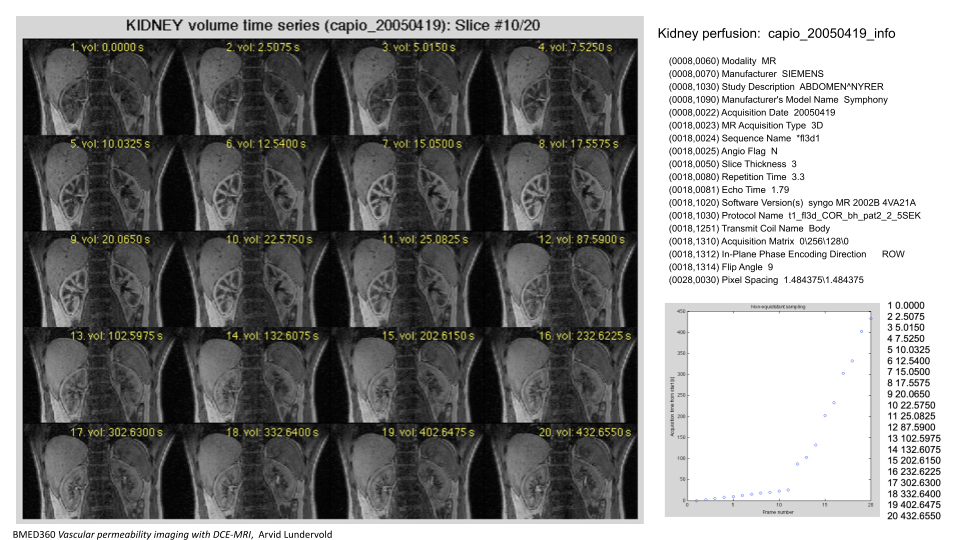

In [8]:
# Illustration: DCE-MRI kidney volume time series (real clinical data)
# Source: BMED360 Lecture 6 (Lundervold, University of Bergen)
from IPython.display import Image, display, HTML

display(Image('../assets/BMED_360_Lec6_vascular_permeability_dce_mri_kidney_volme_time_series_capio_2005.png', width=900))
display(HTML("""
<figcaption style="font-size:0.9em; color:#555; margin-top:4px; text-align:center;">
<b>Figure.</b> <b>3D DCE-MRI kidney volume time series</b> from a clinical examination (Capio, 2005).
Each panel shows the same coronal slice at successive time points after Gd-DTPA injection.
Note the progressive enhancement of the renal cortex (bright rim), followed by medullary
enhancement, and finally excretion into the collecting system (bright pelvis).
The respiratory motion between frames is clearly visible &mdash; motivating the need for
motion correction before quantitative analysis.
<br/><i>Source: BMED360 Lecture 6 &mdash; Vascular permeability and DCE-MRI (A. Lundervold, UiB).</i>
</figcaption>
"""))

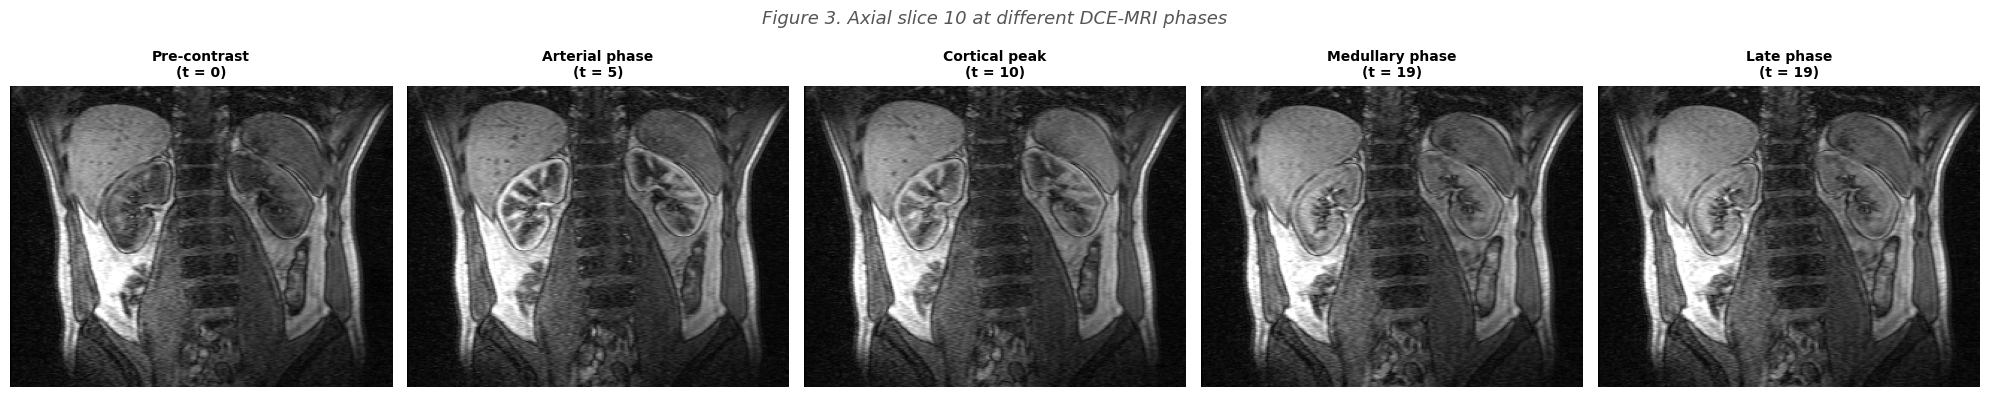

In [9]:
# Anatomical view at different time points
mid_slice = n_z // 2

time_labels = ['Pre-contrast', 'Arterial phase', 'Cortical peak', 'Medullary phase', 'Late phase']
t_indices = [0, min(5, n_t-1), min(10, n_t-1), min(20, n_t-1), min(n_t-1, n_t-1)]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
vmax = np.percentile(data[:, :, mid_slice, :], 99)

for i, (t_idx, label) in enumerate(zip(t_indices, time_labels)):
    ax = axes[i]
    im = ax.imshow(data[:, :, mid_slice, t_idx].T, cmap='gray', origin='upper',
                   vmin=0, vmax=vmax, aspect='auto')
    ax.set_title(f'{label}\n(t = {t_idx})', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle(f'Figure 3. Axial slice {mid_slice} at different DCE-MRI phases', fontsize=13,
             fontstyle='italic', color='#555')
plt.tight_layout()
plt.show()

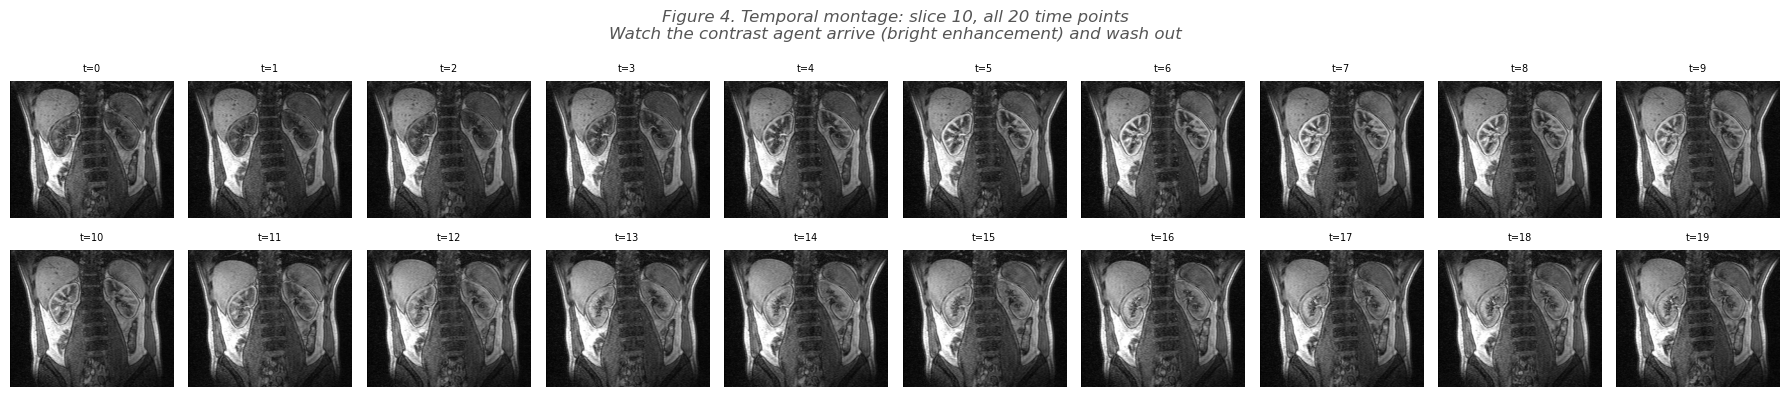

In [10]:
# Temporal montage - all time points for one slice
mid_slice = n_z // 2
n_cols = 10
n_rows = int(np.ceil(n_t / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 2 * n_rows))
vmax = np.percentile(data[:, :, mid_slice, :], 99)

for idx in range(n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    ax = axes[row, col] if n_rows > 1 else axes[col]
    if idx < n_t:
        ax.imshow(data[:, :, mid_slice, idx].T, cmap='gray', origin='upper',
                  vmin=0, vmax=vmax, aspect='auto')
        ax.set_title(f't={idx}', fontsize=7)
    ax.axis('off')

plt.suptitle(f'Figure 4. Temporal montage: slice {mid_slice}, all {n_t} time points\n'
             'Watch the contrast agent arrive (bright enhancement) and wash out',
             fontsize=12, fontstyle='italic', color='#555')
plt.tight_layout()
plt.show()

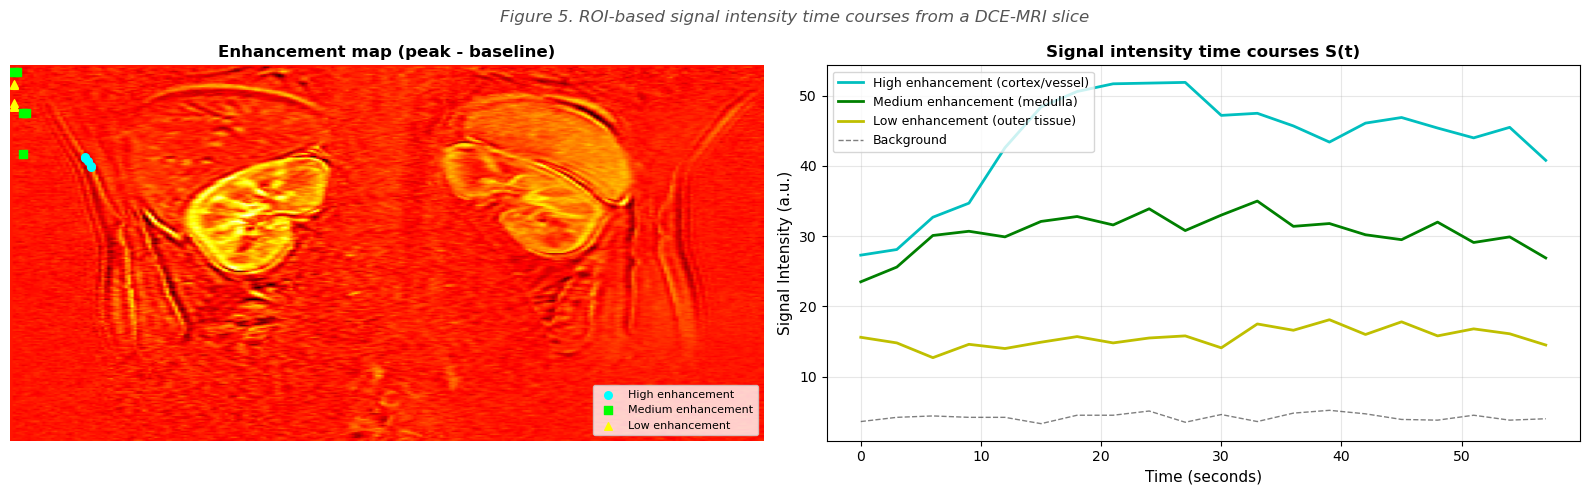

In [11]:
# Signal intensity time courses from selected regions
mid_slice = n_z // 2
slice_data = data[:, :, mid_slice, :]

mean_img = np.mean(slice_data, axis=2)

# Use enhancement map to find regions
baseline = np.mean(slice_data[:, :, :3], axis=2)
peak = np.mean(slice_data[:, :, 8:12], axis=2) if n_t > 12 else np.mean(slice_data[:, :, -3:], axis=2)
diff_img = peak - baseline

mask = diff_img > np.percentile(diff_img, 70)
bright_coords = np.argwhere(mask & (diff_img > np.percentile(diff_img, 95)))
medium_coords = np.argwhere(mask & (diff_img > np.percentile(diff_img, 80)) &
                            (diff_img < np.percentile(diff_img, 90)))
dark_coords = np.argwhere((diff_img > np.percentile(diff_img, 50)) &
                          (diff_img < np.percentile(diff_img, 65)))

def get_roi_timecourse(data_3d, coords, n=5):
    if len(coords) == 0:
        return np.zeros(data_3d.shape[2])
    selected = coords[np.random.choice(len(coords), min(n, len(coords)), replace=False)]
    return np.mean([data_3d[x, y, :] for x, y in selected], axis=0)

np.random.seed(42)
tc_bright = get_roi_timecourse(slice_data, bright_coords, n=10)
tc_medium = get_roi_timecourse(slice_data, medium_coords, n=10)
tc_dark = get_roi_timecourse(slice_data, dark_coords, n=10)
bg_coords = np.argwhere(mean_img < np.percentile(mean_img, 15))
tc_bg = get_roi_timecourse(slice_data, bg_coords, n=10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

im1 = ax1.imshow(diff_img.T, cmap='hot', origin='upper', aspect='auto')
if len(bright_coords) > 0:
    ax1.scatter(bright_coords[:5, 0], bright_coords[:5, 1], c='cyan', s=30, marker='o',
                label='High enhancement')
if len(medium_coords) > 0:
    ax1.scatter(medium_coords[:5, 0], medium_coords[:5, 1], c='lime', s=30, marker='s',
                label='Medium enhancement')
if len(dark_coords) > 0:
    ax1.scatter(dark_coords[:5, 0], dark_coords[:5, 1], c='yellow', s=30, marker='^',
                label='Low enhancement')
ax1.set_title('Enhancement map (peak - baseline)', fontweight='bold')
ax1.legend(fontsize=8, loc='lower right')
ax1.axis('off')

t_axis = np.arange(n_t) * 3.0
ax2.plot(t_axis, tc_bright, 'c-', lw=2, label='High enhancement (cortex/vessel)')
ax2.plot(t_axis, tc_medium, 'g-', lw=2, label='Medium enhancement (medulla)')
ax2.plot(t_axis, tc_dark, 'y-', lw=2, label='Low enhancement (outer tissue)')
ax2.plot(t_axis, tc_bg, 'k--', lw=1, alpha=0.5, label='Background')
ax2.set_xlabel('Time (seconds)', fontsize=11)
ax2.set_ylabel('Signal Intensity (a.u.)', fontsize=11)
ax2.set_title('Signal intensity time courses S(t)', fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.suptitle('Figure 5. ROI-based signal intensity time courses from a DCE-MRI slice',
             fontsize=12, fontstyle='italic', color='#555')
plt.tight_layout()
plt.show()

## 7. Motion Correction in Kidney DCE-MRI

### The problem

During a DCE-MRI acquisition lasting 3–5 minutes, the patient breathes ~40–60 times. Each breath cycle causes the kidneys to translate **1–3 cm** in the craniocaudal (head-to-foot) direction, and also to deform slightly due to compression by the diaphragm and liver.

**Without motion correction**, a single voxel's time course may sample:
- Renal cortex at time $t_1$
- Renal medulla at time $t_2$
- Perirenal fat at time $t_3$

This makes the time course **physiologically meaningless** for compartment model fitting.

### Motion correction strategies

| Strategy | Description | Pros | Cons |
|----------|-------------|------|------|
| **Breath-hold** | Patient holds breath during acquisition | Simple, no post-processing | Limited to ~20 s; poor temporal coverage |
| **Respiratory gating** | Acquire only during one phase of respiration | Good image quality | Long scan times; irregular sampling |
| **Rigid registration** | Translate/rotate each 3D volume to align with a reference | Fast; handles bulk motion | Does not handle deformation |
| **Deformable registration** | Non-rigid warping of each volume | Handles organ deformation | Computationally expensive; risk of artifacts |
| **Segmentation-driven** | Use organ segmentation to guide registration | Robust; physiologically informed | Requires good segmentation |

The **segmentation-driven deformable registration** approach by Hodneland et al. (2014) combines organ segmentation with non-rigid registration, using the kidney boundary to constrain the deformation field. This approach was developed specifically for kidney DCE-MRI at the University of Bergen.

### Illustration: what motion does to time courses

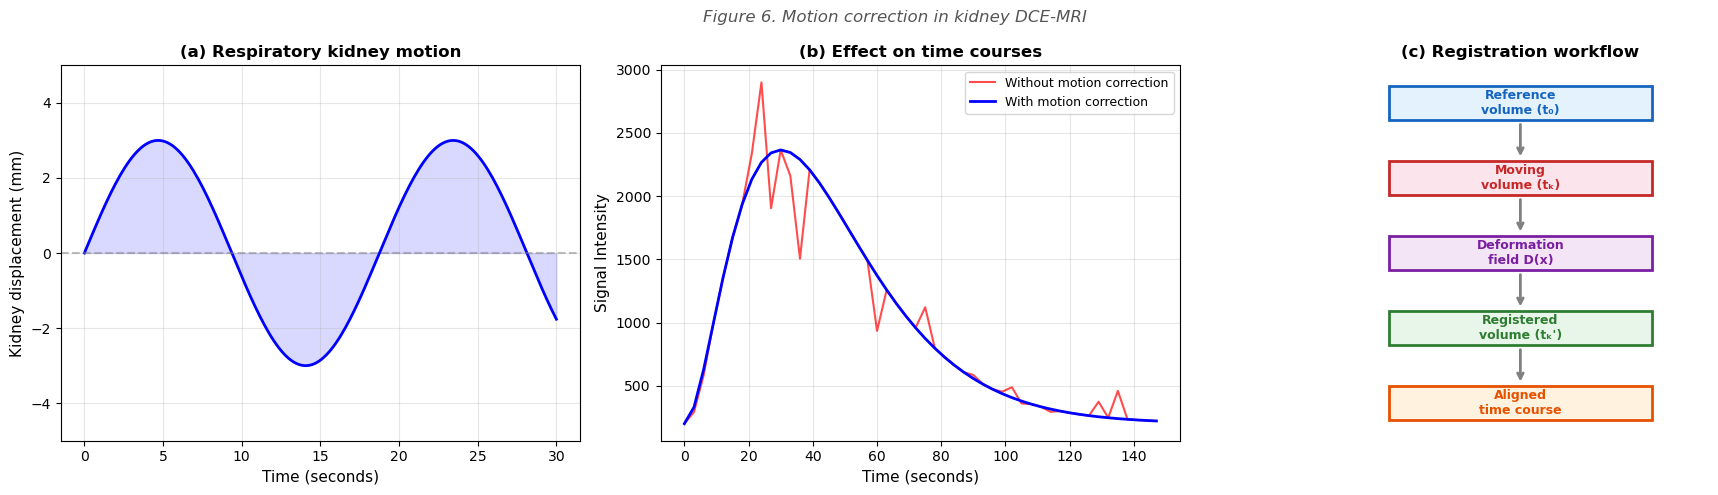

In [12]:
# Illustration of motion effects on DCE-MRI
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Kidney position at different time points
ax = axes[0]
t_positions = np.linspace(0, 4*np.pi, 200)
kidney_y = 3 * np.sin(t_positions * 0.8)
ax.plot(t_positions / (2*np.pi) * 15, kidney_y, 'b-', lw=2)
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Time (seconds)', fontsize=11)
ax.set_ylabel('Kidney displacement (mm)', fontsize=11)
ax.set_title('(a) Respiratory kidney motion', fontweight='bold')
ax.fill_between(t_positions / (2*np.pi) * 15, kidney_y, alpha=0.15, color='blue')
ax.grid(True, alpha=0.3)
ax.set_ylim(-5, 5)

# Panel 2: Effect on time course
ax = axes[1]
np.random.seed(42)
t = np.arange(50)
true_cortex = 200 + 600 * gamma_dist.pdf(t * 3, a=3, scale=15) * 200
motion_noise = np.random.choice([0, 1], size=50, p=[0.6, 0.4])
corrupted = true_cortex.copy()
corrupted[motion_noise == 1] += np.random.normal(0, 80, motion_noise.sum())
corrupted[motion_noise == 1] *= (1 + 0.3 * np.random.randn(motion_noise.sum()))

ax.plot(t * 3, corrupted, 'r-', lw=1.5, alpha=0.7, label='Without motion correction')
ax.plot(t * 3, true_cortex, 'b-', lw=2, label='With motion correction')
ax.set_xlabel('Time (seconds)', fontsize=11)
ax.set_ylabel('Signal Intensity', fontsize=11)
ax.set_title('(b) Effect on time courses', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 3: Registration workflow
ax = axes[2]
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.set_aspect('equal')

steps = [
    (5, 9, 'Reference\nvolume (t\u2080)', '#e3f2fd', '#1565c0'),
    (5, 7, 'Moving\nvolume (t\u2096)', '#fce4ec', '#c62828'),
    (5, 5, 'Deformation\nfield D(x)', '#f3e5f5', '#7b1fa2'),
    (5, 3, 'Registered\nvolume (t\u2096\')', '#e8f5e9', '#2e7d32'),
    (5, 1, 'Aligned\ntime course', '#fff3e0', '#e65100'),
]
for x, y, txt, fc, ec in steps:
    ax.add_patch(plt.Rectangle((1.5, y-0.45), 7, 0.9, facecolor=fc, edgecolor=ec, lw=2, zorder=2))
    ax.text(x, y, txt, ha='center', va='center', fontsize=9, fontweight='bold', color=ec, zorder=3)

for i in range(len(steps)-1):
    ax.annotate('', xy=(5, steps[i+1][1]+0.5), xytext=(5, steps[i][1]-0.5),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2))

ax.set_title('(c) Registration workflow', fontweight='bold')
ax.axis('off')

plt.suptitle('Figure 6. Motion correction in kidney DCE-MRI', fontsize=12,
             fontstyle='italic', color='#555')
plt.tight_layout()
plt.show()

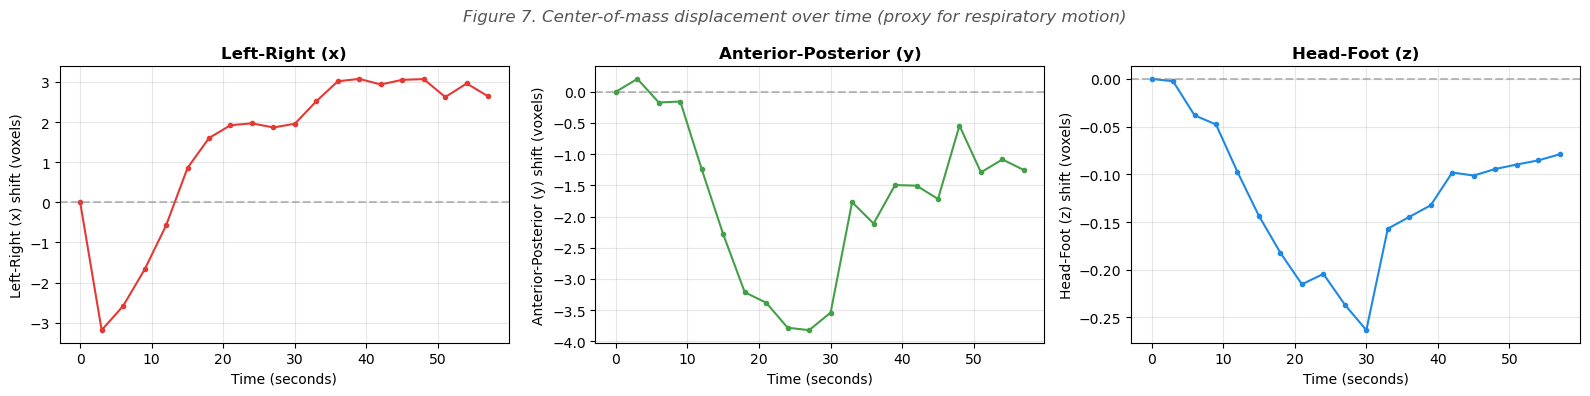

Maximum displacement (voxels): x=6.3, y=4.0, z=0.3


In [13]:
# Quantify apparent motion: center-of-mass shift over time
from scipy.ndimage import center_of_mass

threshold = np.percentile(data, 60)
com_t = []
for t in range(n_t):
    vol = data[:, :, :, t].copy()
    vol[vol < threshold] = 0
    com = center_of_mass(vol)
    com_t.append(com)

com_t = np.array(com_t)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
labels = ['Left-Right (x)', 'Anterior-Posterior (y)', 'Head-Foot (z)']
colors = ['#e53935', '#43a047', '#1e88e5']

for i, (ax, label, color) in enumerate(zip(axes, labels, colors)):
    shift = com_t[:, i] - com_t[0, i]
    ax.plot(np.arange(n_t) * 3, shift, '-o', color=color, markersize=3, lw=1.5)
    ax.set_xlabel('Time (seconds)', fontsize=10)
    ax.set_ylabel(f'{label} shift (voxels)', fontsize=10)
    ax.set_title(label, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', ls='--', alpha=0.5)

plt.suptitle('Figure 7. Center-of-mass displacement over time (proxy for respiratory motion)',
             fontsize=12, fontstyle='italic', color='#555')
plt.tight_layout()
plt.show()

print(f'Maximum displacement (voxels): x={np.ptp(com_t[:,0]):.1f}, '
      f'y={np.ptp(com_t[:,1]):.1f}, z={np.ptp(com_t[:,2]):.1f}')

### DIY: Motion Correction Concepts

**Q4.** If a kidney voxel has size 1.5 × 1.5 × 3.0 mm and respiratory motion causes 15 mm of craniocaudal displacement, how many voxels does the kidney move in the head-foot direction?

<details>
<summary>Click to reveal answer</summary>

$$\text{Displacement in voxels} = \frac{15 \text{ mm}}{3.0 \text{ mm/voxel}} = 5 \text{ voxels}$$

This is a **substantial** displacement — a cortical voxel could easily be replaced by a medullary or even a non-kidney voxel. This illustrates why motion correction is essential before any quantitative analysis.

</details>

**Q5.** What is the key difference between **rigid** and **deformable** registration? When would you prefer one over the other for kidney DCE-MRI?

<details>
<summary>Click to reveal answer</summary>

- **Rigid registration** applies a single global transformation (translation + rotation, 6 parameters in 3D) to the entire image volume. It assumes the organ is a rigid body — it can move and rotate but not change shape.
- **Deformable (non-rigid) registration** allows each voxel to move independently (or nearly so), described by a dense deformation field. It can handle organ compression, stretching, and bending.

For kidney DCE-MRI, **deformable registration** is generally preferred because:
1. The kidney deforms slightly during breathing (compressed by the diaphragm/liver)
2. Different parts of the kidney may move by different amounts
3. Surrounding tissues (liver, spleen, bowel) may push against the kidney differently at each breath phase

However, deformable registration is more computationally expensive and carries the risk of introducing artifacts (e.g., artificial smoothing or distortion of the enhancement pattern). A **segmentation-driven** approach (Hodneland et al., 2014) constrains the deformation to be anatomically plausible.

</details>

## 8. K-means Clustering of Signal Intensity Time Courses

### Motivation: Using time courses as feature vectors

Each voxel in the 4D DCE-MRI dataset has a **signal intensity time course** — a vector in $\mathbf{R}^{N_t}$ (e.g., $\mathbf{R}^{50}$ if there are 50 time points). The idea is elegant:

> **Voxels with similar physiology produce similar time courses.**

- Cortical voxels (high perfusion, rapid enhancement and washout) cluster together
- Medullary voxels (delayed enhancement, slow washout) cluster together
- Vascular voxels (very rapid, sharp peak) cluster together
- Background voxels (no enhancement) cluster together

**K-means clustering** groups voxels based on the **similarity of their entire time course**, treating each time course as a point in high-dimensional feature space ($\mathbf{R}^{N_t}$).

### The K-means algorithm

Given $N$ data points (voxel time courses) $\{\mathbf{x}_1, \ldots, \mathbf{x}_N\} \subset \mathbf{R}^{N_t}$ and a desired number of clusters $K$:

1. **Initialize** $K$ cluster centroids $\{\boldsymbol{\mu}_1, \ldots, \boldsymbol{\mu}_K\}$ (e.g., K-means++ initialization)
2. **Assign** each point to its nearest centroid: $c_i = \arg\min_k \|\mathbf{x}_i - \boldsymbol{\mu}_k\|^2$
3. **Update** centroids as the mean of assigned points: $\boldsymbol{\mu}_k = \frac{1}{|C_k|} \sum_{i \in C_k} \mathbf{x}_i$
4. **Repeat** steps 2–3 until convergence (assignments stop changing)

The centroids $\boldsymbol{\mu}_k$ represent **prototypic time courses** — one for each tissue type identified by the algorithm.

In [14]:
# K-means clustering of voxel time courses
mid_slice = n_z // 2
slice_data = data[:, :, mid_slice, :]

nx, ny, nt = slice_data.shape
X = slice_data.reshape(-1, nt)

mean_signal = np.mean(X, axis=1)
threshold = np.percentile(mean_signal, 25)
mask_foreground = mean_signal > threshold

# Normalize time courses
X_norm = np.zeros_like(X, dtype=np.float64)
X_norm[mask_foreground] = (X[mask_foreground] - X[mask_foreground].mean(axis=1, keepdims=True))
std = X[mask_foreground].std(axis=1, keepdims=True)
std[std == 0] = 1
X_norm[mask_foreground] /= std

K = 8
print(f'Running K-means with K={K} on {mask_foreground.sum():,} foreground voxels '
      f'in R^{nt} feature space...')

kmeans = KMeans(n_clusters=K, n_init=10, random_state=42, max_iter=300)
labels_flat = np.full(nx * ny, -1, dtype=int)
labels_flat[mask_foreground] = kmeans.fit_predict(X_norm[mask_foreground])

label_map = labels_flat.reshape(nx, ny)
print(f'K-means converged in {kmeans.n_iter_} iterations')

for k in range(K):
    n_voxels = np.sum(labels_flat == k)
    print(f'  Cluster {k}: {n_voxels:,} voxels ({100*n_voxels/mask_foreground.sum():.1f}%)')

Running K-means with K=8 on 49,123 foreground voxels in R^20 feature space...
K-means converged in 62 iterations
  Cluster 0: 6,322 voxels (12.9%)
  Cluster 1: 9,608 voxels (19.6%)
  Cluster 2: 6,430 voxels (13.1%)
  Cluster 3: 7,071 voxels (14.4%)
  Cluster 4: 4,975 voxels (10.1%)
  Cluster 5: 5,355 voxels (10.9%)
  Cluster 6: 5,246 voxels (10.7%)
  Cluster 7: 4,116 voxels (8.4%)


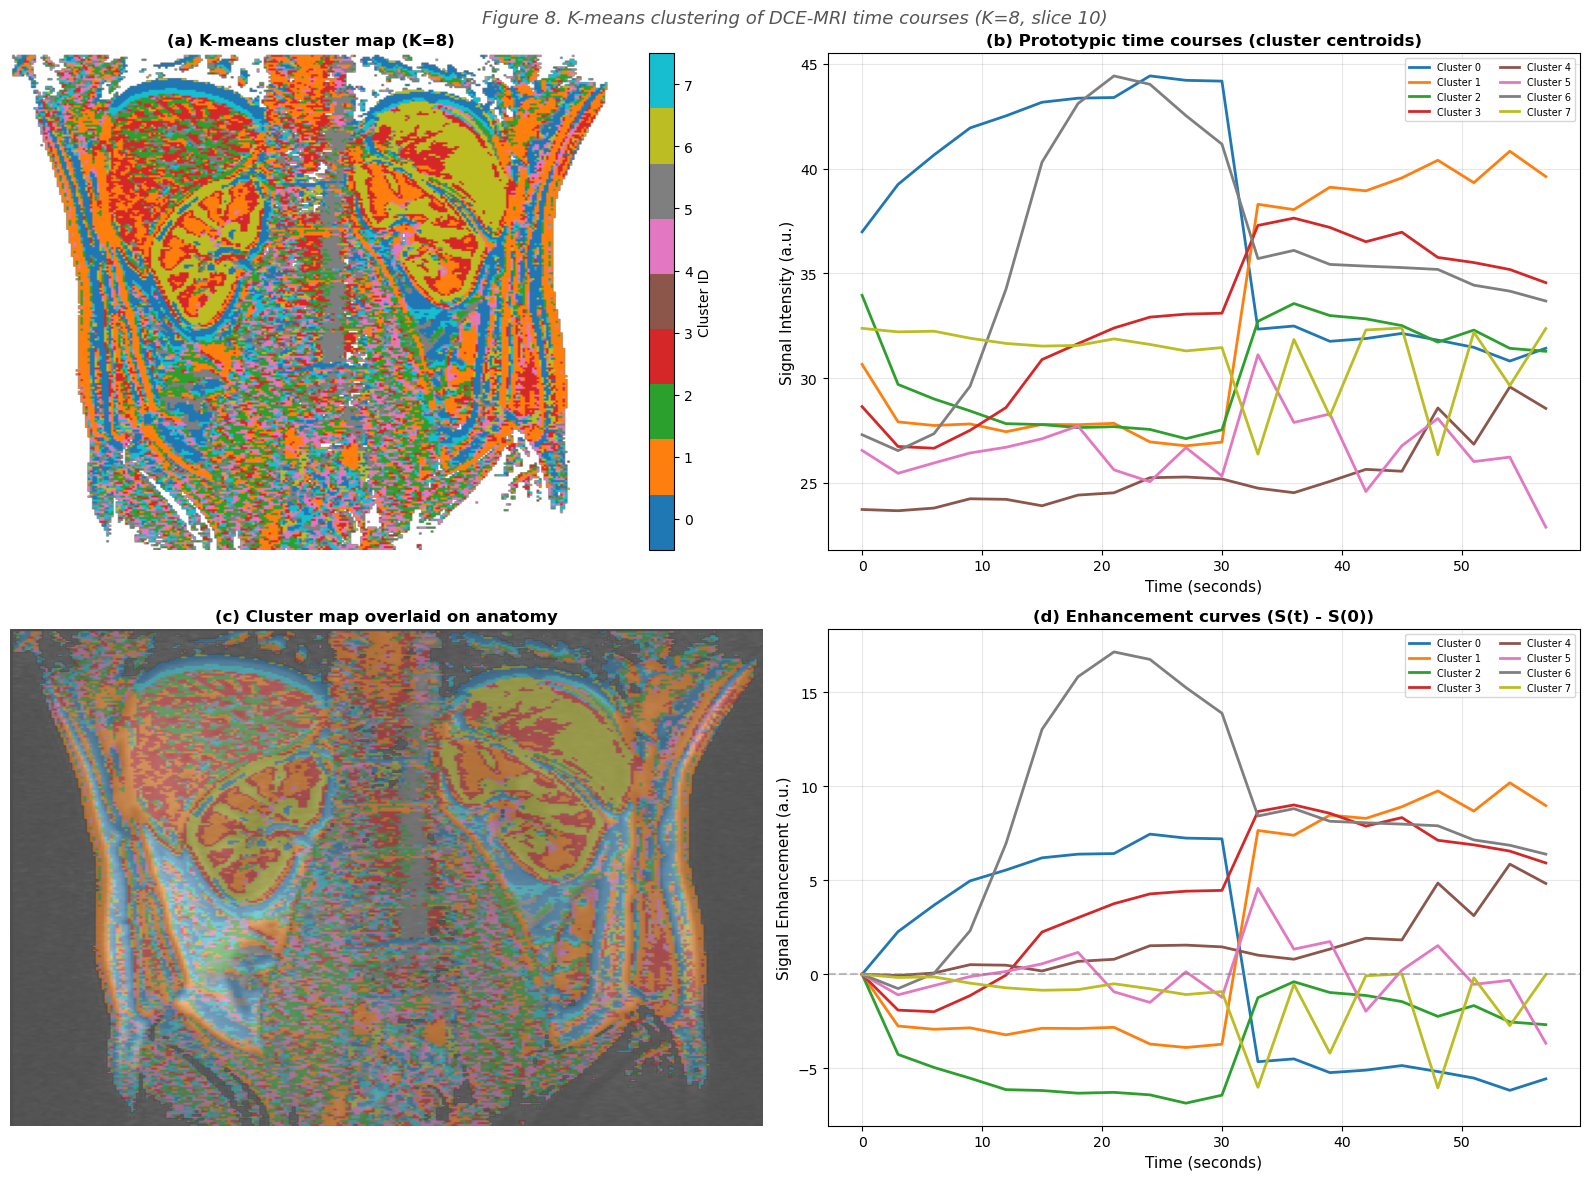

In [15]:
# K-means clustering results visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (a) Cluster map
ax = axes[0, 0]
cmap = plt.cm.get_cmap('tab10', K + 1)
label_display = label_map.copy().astype(float)
label_display[label_map == -1] = np.nan
im = ax.imshow(label_display.T, cmap=cmap, origin='upper', vmin=-0.5, vmax=K-0.5, aspect='auto')
ax.set_title(f'(a) K-means cluster map (K={K})', fontweight='bold', fontsize=12)
plt.colorbar(im, ax=ax, ticks=range(K), label='Cluster ID')
ax.axis('off')

# (b) Cluster centroids
ax = axes[0, 1]
t_axis = np.arange(nt) * 3.0
centroids_original = []
for k in range(K):
    cluster_voxels = X[labels_flat == k]
    centroid_orig = np.mean(cluster_voxels, axis=0)
    centroids_original.append(centroid_orig)
    color = cmap(k / K)
    ax.plot(t_axis, centroid_orig, '-', color=color, lw=2, label=f'Cluster {k}')

ax.set_xlabel('Time (seconds)', fontsize=11)
ax.set_ylabel('Signal Intensity (a.u.)', fontsize=11)
ax.set_title('(b) Prototypic time courses (cluster centroids)', fontweight='bold', fontsize=12)
ax.legend(fontsize=7, ncol=2, loc='upper right')
ax.grid(True, alpha=0.3)

# (c) Overlay on anatomy
ax = axes[1, 0]
baseline_img = np.mean(slice_data[:, :, :3], axis=2)
ax.imshow(baseline_img.T, cmap='gray', origin='upper', aspect='auto', alpha=0.7)
overlay = np.ma.masked_where(label_map == -1, label_map)
ax.imshow(overlay.T, cmap=cmap, origin='upper', vmin=-0.5, vmax=K-0.5, aspect='auto', alpha=0.5)
ax.set_title('(c) Cluster map overlaid on anatomy', fontweight='bold', fontsize=12)
ax.axis('off')

# (d) Enhancement curves
ax = axes[1, 1]
for k in range(K):
    c = centroids_original[k]
    enhancement = c - c[0]
    color = cmap(k / K)
    ax.plot(t_axis, enhancement, '-', color=color, lw=2, label=f'Cluster {k}')
ax.set_xlabel('Time (seconds)', fontsize=11)
ax.set_ylabel('Signal Enhancement (a.u.)', fontsize=11)
ax.set_title('(d) Enhancement curves (S(t) - S(0))', fontweight='bold', fontsize=12)
ax.legend(fontsize=7, ncol=2, loc='upper right')
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', ls='--', alpha=0.5)

plt.suptitle(f'Figure 8. K-means clustering of DCE-MRI time courses (K={K}, slice {mid_slice})',
             fontsize=13, fontstyle='italic', color='#555')
plt.tight_layout()
plt.show()

## 9. K-means "Smoothing" of Time Courses

### The noise problem

Individual voxel time courses in DCE-MRI are inherently **noisy** due to:
- Thermal noise in the MRI receiver coils
- Physiological noise (pulsation, motion residuals)
- Partial volume effects (voxels containing multiple tissue types)

### K-means smoothing concept

**K-means smoothing** is an elegant approach to noise reduction:

1. Apply K-means clustering with a **large K** (e.g., K = 64) to the voxel time courses
2. Replace each voxel's noisy time course with its **cluster centroid** (the average of all voxels in that cluster)

This is a form of **adaptive spatial smoothing** — it averages voxels that have similar temporal dynamics, respecting tissue boundaries. Unlike Gaussian spatial smoothing, which blurs across boundaries, K-means smoothing preserves the distinct enhancement patterns of cortex and medulla.

> **Key insight**: With K = 64 clusters and ~50 time points, each centroid is the average of many voxels (typically 50–500), reducing noise by a factor of ~$\sqrt{N_{cluster}}$ while preserving the tissue-specific signal dynamics.

The feature space is $\mathbf{R}^{N_t}$ (e.g., $\mathbf{R}^{50}$), and the 64 centroids represent **64 prototypic time courses** that capture the main patterns in the data.

Running K-means smoothing with K=64 clusters...
K-means converged in 181 iterations
  64 prototypic time courses in R^20


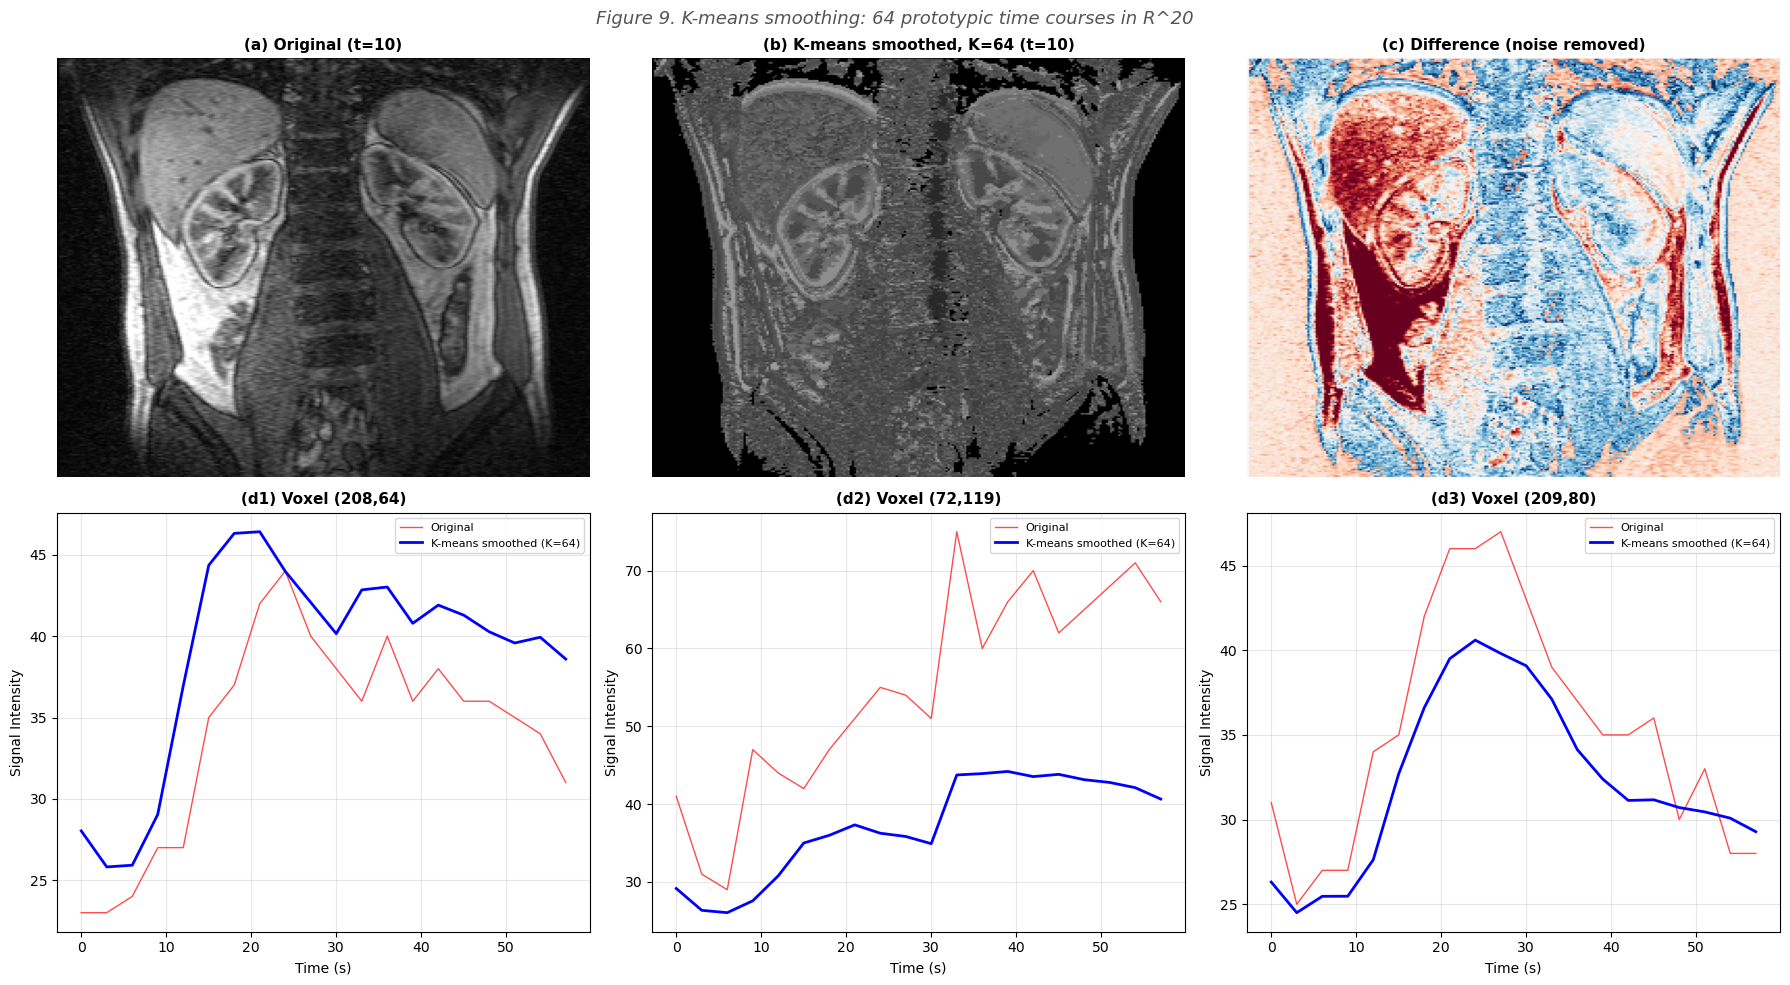

In [16]:
# K-means smoothing with K=64 prototypic time courses
K_smooth = 64
print(f'Running K-means smoothing with K={K_smooth} clusters...')

kmeans_smooth = KMeans(n_clusters=K_smooth, n_init=5, random_state=42, max_iter=200)
labels_smooth = np.full(nx * ny, -1, dtype=int)
labels_smooth[mask_foreground] = kmeans_smooth.fit_predict(X_norm[mask_foreground])

print(f'K-means converged in {kmeans_smooth.n_iter_} iterations')
print(f'  {K_smooth} prototypic time courses in R^{nt}')

# Compute smoothed image
X_smoothed = np.zeros_like(X, dtype=np.float64)
for k in range(K_smooth):
    cluster_mask = labels_smooth == k
    if cluster_mask.any():
        centroid = np.mean(X[cluster_mask], axis=0)
        X_smoothed[cluster_mask] = centroid

smoothed_slice = X_smoothed.reshape(nx, ny, nt)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

t_show = min(10, nt - 1)
vmax = np.percentile(data[:, :, mid_slice, t_show], 99)

axes[0, 0].imshow(slice_data[:, :, t_show].T, cmap='gray', origin='upper',
                   vmin=0, vmax=vmax, aspect='auto')
axes[0, 0].set_title(f'(a) Original (t={t_show})', fontweight='bold', fontsize=11)
axes[0, 0].axis('off')

axes[0, 1].imshow(smoothed_slice[:, :, t_show].T, cmap='gray', origin='upper',
                   vmin=0, vmax=vmax, aspect='auto')
axes[0, 1].set_title(f'(b) K-means smoothed, K={K_smooth} (t={t_show})', fontweight='bold', fontsize=11)
axes[0, 1].axis('off')

diff = slice_data[:, :, t_show] - smoothed_slice[:, :, t_show]
axes[0, 2].imshow(diff.T, cmap='RdBu_r', origin='upper', aspect='auto',
                   vmin=-np.percentile(np.abs(diff), 95), vmax=np.percentile(np.abs(diff), 95))
axes[0, 2].set_title('(c) Difference (noise removed)', fontweight='bold', fontsize=11)
axes[0, 2].axis('off')

# Time course comparisons
np.random.seed(123)
if len(bright_coords) >= 3:
    sample_voxels = bright_coords[np.random.choice(len(bright_coords), 3, replace=False)]
else:
    sample_voxels = np.argwhere(mask_foreground.reshape(nx, ny))[:3]

for idx, (vx, vy) in enumerate(sample_voxels):
    ax = axes[1, idx]
    orig_tc = slice_data[vx, vy, :]
    smooth_tc = smoothed_slice[vx, vy, :]
    ax.plot(t_axis, orig_tc, 'r-', lw=1, alpha=0.7, label='Original')
    ax.plot(t_axis, smooth_tc, 'b-', lw=2, label=f'K-means smoothed (K={K_smooth})')
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_ylabel('Signal Intensity', fontsize=10)
    ax.set_title(f'(d{idx+1}) Voxel ({vx},{vy})', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Figure 9. K-means smoothing: {K_smooth} prototypic time courses in R^{nt}',
             fontsize=13, fontstyle='italic', color='#555')
plt.tight_layout()
plt.show()

### DIY: K-means Clustering and Smoothing

**Q6.** In a DCE-MRI dataset with 50 time points, each voxel's time course is a vector in $\mathbf{R}^{50}$. If K-means with K=8 assigns 1,000 voxels to a cluster, what is the expected noise reduction factor for that cluster's centroid compared to a single voxel?

<details>
<summary>Click to reveal answer</summary>

If the noise in each voxel is independent with standard deviation $\sigma$, then the centroid (average of $N = 1000$ voxels) has standard deviation:

$$\sigma_{centroid} = \frac{\sigma}{\sqrt{N}} = \frac{\sigma}{\sqrt{1000}} \approx \frac{\sigma}{31.6}$$

So the **noise reduction factor** is approximately **31.6x**. This dramatic noise reduction enables much more reliable curve fitting for compartment models.

Note: This assumes the noise is purely random and identical across voxels. In practice, structured noise (e.g., from residual motion) may not average out as cleanly.

</details>

**Q7.** Why might you choose K=64 rather than, say, K=4 for K-means smoothing? What is the trade-off?

<details>
<summary>Click to reveal answer</summary>

**K=64** provides a better trade-off between noise reduction and spatial fidelity:

- With **K=4**, only 4 prototypic patterns are allowed. The smoothed image would lose fine details — e.g., it might merge cortical and medullary patterns, or fail to distinguish different cortical zones. This is **over-smoothing**.
- With **K=64**, the algorithm can represent 64 distinct temporal patterns. This preserves gradients across the cortex-medulla boundary, captures vascular structures, and retains enough spatial detail for meaningful GFR mapping. Each cluster still contains many voxels (typically 50–500), so noise reduction remains substantial.
- With **very large K** (e.g., K=5000), each cluster contains very few voxels, providing minimal noise reduction and approaching the original noisy data.

The optimal K depends on:
- The **spatial heterogeneity** of the tissue (more heterogeneous = higher K)
- The **SNR** of the data (noisier data = lower K for more averaging)
- The **downstream analysis** requirements (voxel-wise GFR mapping needs higher K)

In practice, K=32–128 is a common range for kidney DCE-MRI smoothing.

</details>

## 10. Tracer Kinetics and Compartment Modeling

### Overview

The goal of compartment modeling in kidney DCE-MRI is to extract **physiological parameters** (perfusion, GFR, tubular transit time) from the observed signal intensity time courses. This requires:

1. Converting signal intensity $S(t)$ to contrast agent concentration $C(t)$
2. Measuring or estimating the **Arterial Input Function** $C_a(t)$
3. Fitting a **compartment model** to the tissue concentration curve

### The General Tracer Kinetic Equation

For a linear, time-invariant system, the tissue concentration is related to the arterial input by a **convolution**:

$$C_{tissue}(t) = F_p \cdot C_a(t) \otimes R(t) = F_p \int_0^t C_a(\tau) \cdot R(t - \tau) \, d\tau$$

where:
- $F_p$ = plasma flow (mL/min/mL tissue)
- $C_a(t)$ = arterial input function
- $R(t)$ = **impulse residue function** (the fraction of tracer still in the tissue at time $t$ after an instantaneous input)
- $\otimes$ = convolution operator

Different compartment models correspond to different forms of $R(t)$.

### The Two-Compartment Filtration Model for Kidney

For the kidney, a commonly used model has two tissue compartments:

1. **Plasma compartment** (volume fraction $v_p$): Blood plasma in glomerular and peritubular capillaries
2. **Tubular compartment** (volume fraction $v_t$): Filtrate in the tubules

The model equations are:

$$\frac{d\,v_p \cdot C_p(t)}{dt} = F_p \cdot [C_a(t) - C_p(t)] - GFR \cdot C_p(t)$$

$$\frac{d\,v_t \cdot C_t(t)}{dt} = GFR \cdot C_p(t) - T_t^{-1} \cdot v_t \cdot C_t(t)$$

$$C_{tissue}(t) = v_p \cdot C_p(t) + v_t \cdot C_t(t)$$

where:
- $F_p$ = plasma flow rate per unit tissue volume (mL/min/mL)
- $GFR$ = glomerular filtration rate per unit tissue volume (mL/min/mL)
- $T_t$ = mean tubular transit time (min)

The **Filtration Fraction** is $FF = GFR / F_p$.

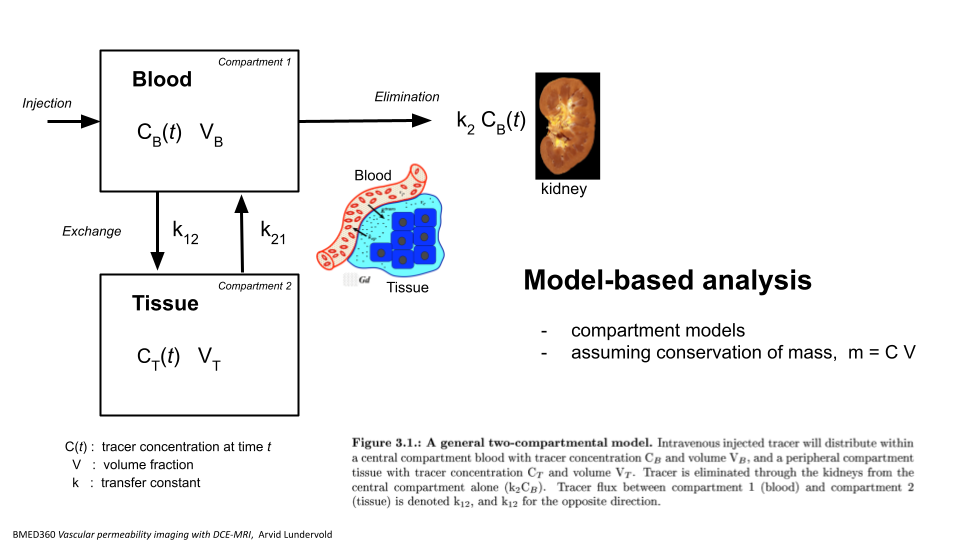

In [17]:
# Illustration: Model-based analysis of DCE-MRI data
# Source: BMED360 Lecture 6 (Lundervold, University of Bergen)
from IPython.display import Image, display, HTML

display(Image('../assets/BMED_360_Lec6_vascular_permeability_dce_mri_model_based_analysis.png', width=800))
display(HTML("""
<figcaption style="font-size:0.9em; color:#555; margin-top:4px; text-align:center;">
<b>Figure.</b> <b>Model-based analysis</b> of DCE-MRI data. The concentration-time curve in each
voxel (or ROI) is fitted to a pharmacokinetic compartment model, yielding quantitative parameter
maps (e.g., perfusion, GFR, transit time). The arterial input function (AIF) serves as the
driving input to the model.
<br/><i>Source: BMED360 Lecture 6 &mdash; Vascular permeability and DCE-MRI (A. Lundervold, UiB).</i>
</figcaption>
"""))

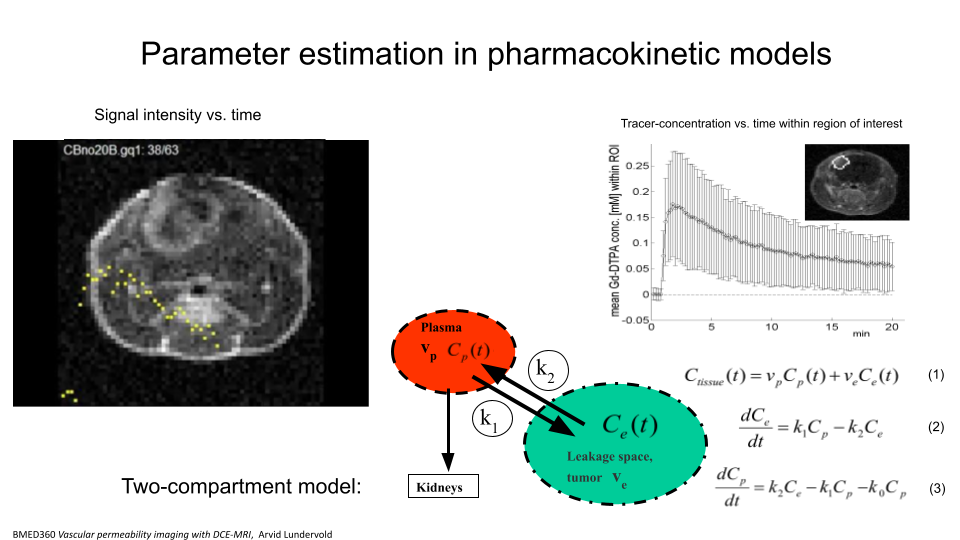

In [18]:
# Illustration: Pharmacokinetic model for DCE-MRI
# Source: BMED360 Lecture 6 (Lundervold, University of Bergen)

display(Image('../assets/BMED_360_Lec6_vascular_permeability_dce_mri_pharmacokinetic_model.png', width=800))
display(HTML("""
<figcaption style="font-size:0.9em; color:#555; margin-top:4px; text-align:center;">
<b>Figure.</b> <b>Pharmacokinetic compartment model</b> for DCE-MRI analysis.
The model describes the exchange of contrast agent between the vascular (plasma) space
and the extravascular extracellular space (EES), governed by the transfer constant
<i>K<sup>trans</sup></i> and the rate constant <i>k<sub>ep</sub></i>.
For the kidney, the "EES" is replaced by the <b>tubular compartment</b>,
and <i>K<sup>trans</sup></i> corresponds to the <b>GFR</b> (per unit tissue volume).
<br/><i>Source: BMED360 Lecture 6 &mdash; Vascular permeability and DCE-MRI (A. Lundervold, UiB).</i>
</figcaption>
"""))

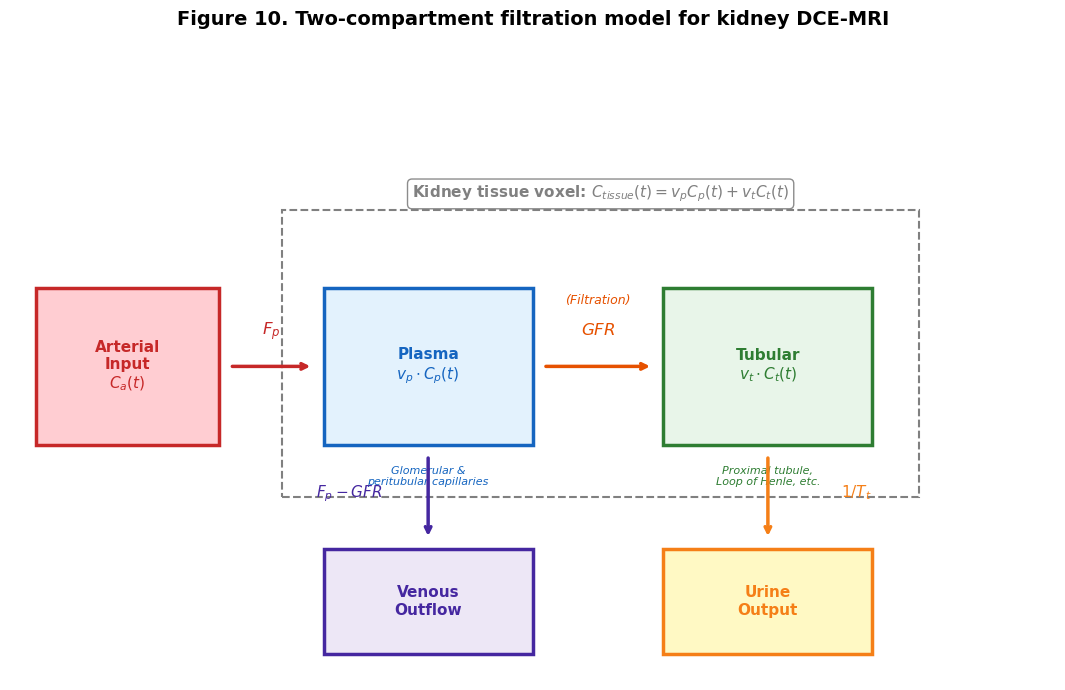

In [19]:
# Two-compartment kidney model diagram
fig, ax = plt.subplots(1, 1, figsize=(14, 7))
ax.set_xlim(0, 20); ax.set_ylim(0, 12)
ax.set_aspect('equal')

# Boxes
ax.add_patch(plt.Rectangle((0.5, 4.5), 3.5, 3, facecolor='#ffcdd2', edgecolor='#c62828', lw=2.5, zorder=2))
ax.text(2.25, 6, 'Arterial\nInput\n$C_a(t)$', ha='center', va='center', fontsize=11, fontweight='bold', color='#c62828', zorder=3)

ax.add_patch(plt.Rectangle((6, 4.5), 4, 3, facecolor='#e3f2fd', edgecolor='#1565c0', lw=2.5, zorder=2))
ax.text(8, 6, 'Plasma\n$v_p \\cdot C_p(t)$', ha='center', va='center', fontsize=11, fontweight='bold', color='#1565c0', zorder=3)
ax.text(8, 4.1, 'Glomerular &\nperitubular capillaries', ha='center', va='top', fontsize=8, color='#1565c0', style='italic')

ax.add_patch(plt.Rectangle((12.5, 4.5), 4, 3, facecolor='#e8f5e9', edgecolor='#2e7d32', lw=2.5, zorder=2))
ax.text(14.5, 6, 'Tubular\n$v_t \\cdot C_t(t)$', ha='center', va='center', fontsize=11, fontweight='bold', color='#2e7d32', zorder=3)
ax.text(14.5, 4.1, 'Proximal tubule,\nLoop of Henle, etc.', ha='center', va='top', fontsize=8, color='#2e7d32', style='italic')

ax.add_patch(plt.Rectangle((6, 0.5), 4, 2, facecolor='#ede7f6', edgecolor='#4527a0', lw=2.5, zorder=2))
ax.text(8, 1.5, 'Venous\nOutflow', ha='center', va='center', fontsize=11, fontweight='bold', color='#4527a0', zorder=3)

ax.add_patch(plt.Rectangle((12.5, 0.5), 4, 2, facecolor='#fff9c4', edgecolor='#f57f17', lw=2.5, zorder=2))
ax.text(14.5, 1.5, 'Urine\nOutput', ha='center', va='center', fontsize=11, fontweight='bold', color='#f57f17', zorder=3)

# Tissue box
ax.add_patch(plt.Rectangle((5.2, 3.5), 12.2, 5.5, facecolor='none', edgecolor='gray', lw=1.5, ls='--', zorder=1))
ax.text(11.3, 9.3, 'Kidney tissue voxel: $C_{tissue}(t) = v_p C_p(t) + v_t C_t(t)$',
        ha='center', va='center', fontsize=11, fontweight='bold', color='gray',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.9))

# Arrows
ax.annotate('', xy=(5.8, 6), xytext=(4.2, 6), arrowprops=dict(arrowstyle='->', color='#c62828', lw=2.5))
ax.text(5, 6.6, '$F_p$', ha='center', fontsize=12, fontweight='bold', color='#c62828')

ax.annotate('', xy=(12.3, 6), xytext=(10.2, 6), arrowprops=dict(arrowstyle='->', color='#e65100', lw=2.5))
ax.text(11.25, 6.6, '$GFR$', ha='center', fontsize=12, fontweight='bold', color='#e65100')
ax.text(11.25, 7.2, '(Filtration)', ha='center', fontsize=9, color='#e65100', style='italic')

ax.annotate('', xy=(8, 2.7), xytext=(8, 4.3), arrowprops=dict(arrowstyle='->', color='#4527a0', lw=2.5))
ax.text(6.5, 3.5, '$F_p - GFR$', ha='center', fontsize=11, fontweight='bold', color='#4527a0')

ax.annotate('', xy=(14.5, 2.7), xytext=(14.5, 4.3), arrowprops=dict(arrowstyle='->', color='#f57f17', lw=2.5))
ax.text(16.2, 3.5, '$1/T_t$', ha='center', fontsize=11, fontweight='bold', color='#f57f17')

ax.set_title('Figure 10. Two-compartment filtration model for kidney DCE-MRI',
             fontsize=14, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.show()

Normal kidney cortex parameters:
  Plasma flow (Fp):        3.0 mL/min/mL
  GFR density:             0.50 mL/min/mL
  Filtration fraction (FF): 16.7%
  Plasma volume (vp):      0.15
  Tubular volume (vt):     0.10
  Tubular transit time:    2.0 min


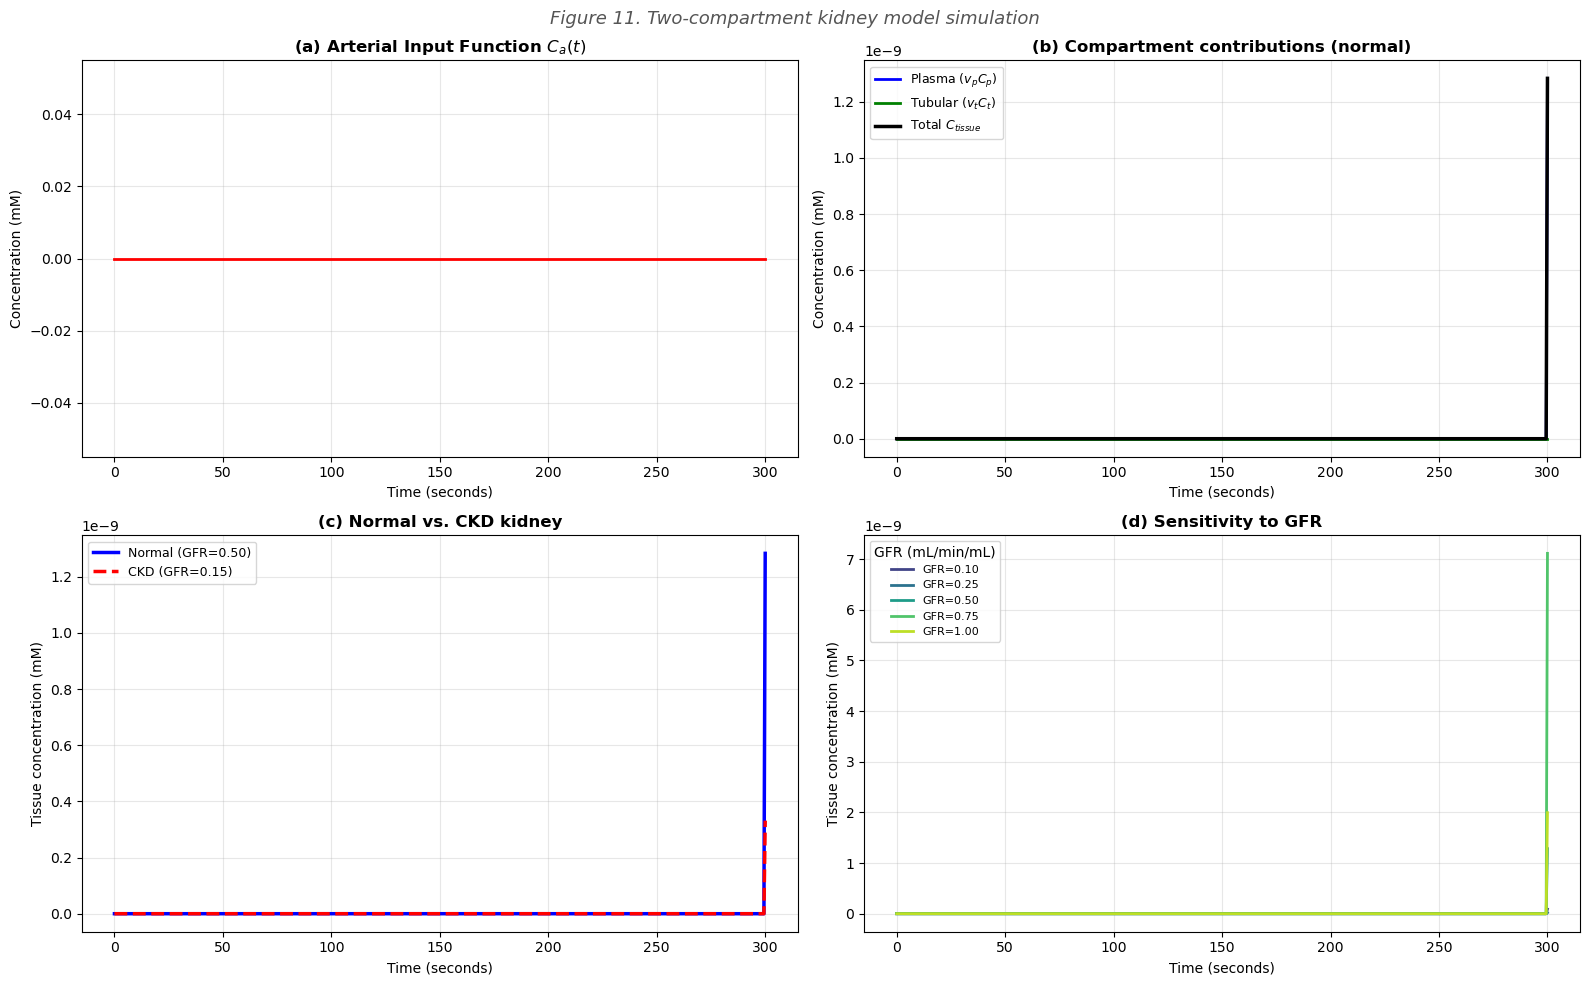

In [20]:
# Simulate the two-compartment kidney model

def arterial_input_function(t, A1=6.0, m1=0.15, A2=1.5, m2=0.02, t0=5.0):
    """Population-averaged AIF model (bi-exponential after bolus arrival)."""
    t_shifted = np.maximum(t - t0, 0)
    return A1 * t_shifted * np.exp(-m1 * t_shifted) + A2 * np.exp(-m2 * t_shifted) * (t > t0)

def kidney_2compartment(y, t, Fp, GFR_d, vp, vt, Tt, aif_func):
    """Two-compartment kidney model ODEs."""
    Cp, Ct = y
    Ca = aif_func(t)
    dCp_dt = (Fp * (Ca - Cp) - GFR_d * Cp) / vp
    dCt_dt = (GFR_d * Cp - Ct / Tt) / vt if vt > 0 else 0
    return [dCp_dt, dCt_dt]

# Normal kidney cortex parameters
Fp = 3.0; GFR_d = 0.5; vp = 0.15; vt = 0.10; Tt = 2.0
FF = GFR_d / Fp

print('Normal kidney cortex parameters:')
print(f'  Plasma flow (Fp):        {Fp:.1f} mL/min/mL')
print(f'  GFR density:             {GFR_d:.2f} mL/min/mL')
print(f'  Filtration fraction (FF): {FF:.1%}')
print(f'  Plasma volume (vp):      {vp:.2f}')
print(f'  Tubular volume (vt):     {vt:.2f}')
print(f'  Tubular transit time:    {Tt:.1f} min')

t_model = np.linspace(0, 5, 500)
y0 = [0.0, 0.0]
sol = odeint(kidney_2compartment, y0, t_model, args=(Fp, GFR_d, vp, vt, Tt, arterial_input_function))
Cp_sol = sol[:, 0]; Ct_sol = sol[:, 1]
C_tissue = vp * Cp_sol + vt * Ct_sol
C_aif = np.array([arterial_input_function(t) for t in t_model])

# Diseased kidney
GFR_d_diseased = 0.15
sol_d = odeint(kidney_2compartment, y0, t_model, args=(Fp*0.7, GFR_d_diseased, vp, vt, Tt*1.5, arterial_input_function))
C_tissue_diseased = vp * sol_d[:, 0] + vt * sol_d[:, 1]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(t_model*60, C_aif, 'r-', lw=2)
axes[0,0].set_xlabel('Time (seconds)'); axes[0,0].set_ylabel('Concentration (mM)')
axes[0,0].set_title('(a) Arterial Input Function $C_a(t)$', fontweight='bold')
axes[0,0].fill_between(t_model*60, C_aif, alpha=0.15, color='red')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(t_model*60, vp*Cp_sol, 'b-', lw=2, label='Plasma ($v_p C_p$)')
axes[0,1].plot(t_model*60, vt*Ct_sol, 'g-', lw=2, label='Tubular ($v_t C_t$)')
axes[0,1].plot(t_model*60, C_tissue, 'k-', lw=2.5, label='Total $C_{tissue}$')
axes[0,1].set_xlabel('Time (seconds)'); axes[0,1].set_ylabel('Concentration (mM)')
axes[0,1].set_title('(b) Compartment contributions (normal)', fontweight='bold')
axes[0,1].legend(fontsize=9); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(t_model*60, C_tissue, 'b-', lw=2.5, label=f'Normal (GFR={GFR_d:.2f})')
axes[1,0].plot(t_model*60, C_tissue_diseased, 'r--', lw=2.5, label=f'CKD (GFR={GFR_d_diseased:.2f})')
axes[1,0].set_xlabel('Time (seconds)'); axes[1,0].set_ylabel('Tissue concentration (mM)')
axes[1,0].set_title('(c) Normal vs. CKD kidney', fontweight='bold')
axes[1,0].legend(fontsize=9); axes[1,0].grid(True, alpha=0.3)

gfr_values = [0.1, 0.25, 0.5, 0.75, 1.0]
colors_gfr = plt.cm.viridis(np.linspace(0.2, 0.9, len(gfr_values)))
for gfr_val, col in zip(gfr_values, colors_gfr):
    sol_i = odeint(kidney_2compartment, y0, t_model, args=(Fp, gfr_val, vp, vt, Tt, arterial_input_function))
    C_i = vp * sol_i[:, 0] + vt * sol_i[:, 1]
    axes[1,1].plot(t_model*60, C_i, '-', color=col, lw=2, label=f'GFR={gfr_val:.2f}')
axes[1,1].set_xlabel('Time (seconds)'); axes[1,1].set_ylabel('Tissue concentration (mM)')
axes[1,1].set_title('(d) Sensitivity to GFR', fontweight='bold')
axes[1,1].legend(fontsize=8, title='GFR (mL/min/mL)'); axes[1,1].grid(True, alpha=0.3)

plt.suptitle('Figure 11. Two-compartment kidney model simulation', fontsize=13, fontstyle='italic', color='#555')
plt.tight_layout()
plt.show()

Compartment Model Fitting Results
Parameter        True  Estimated  Std Error   Error%
-----------------------------------------------------------------
  Fp            3.000      1.997      0.000    33.4%
  GFR_d         0.500      0.300      0.000    40.0%
  vp            0.150      0.113      0.248    24.4%
  vt            0.100      0.100      0.000     0.0%
  Tt            2.000      1.500      0.000    25.0%

  Single-kidney GFR (V_kidney = 150 mL):
    True:      75.0 mL/min
    Estimated: 45.0 mL/min


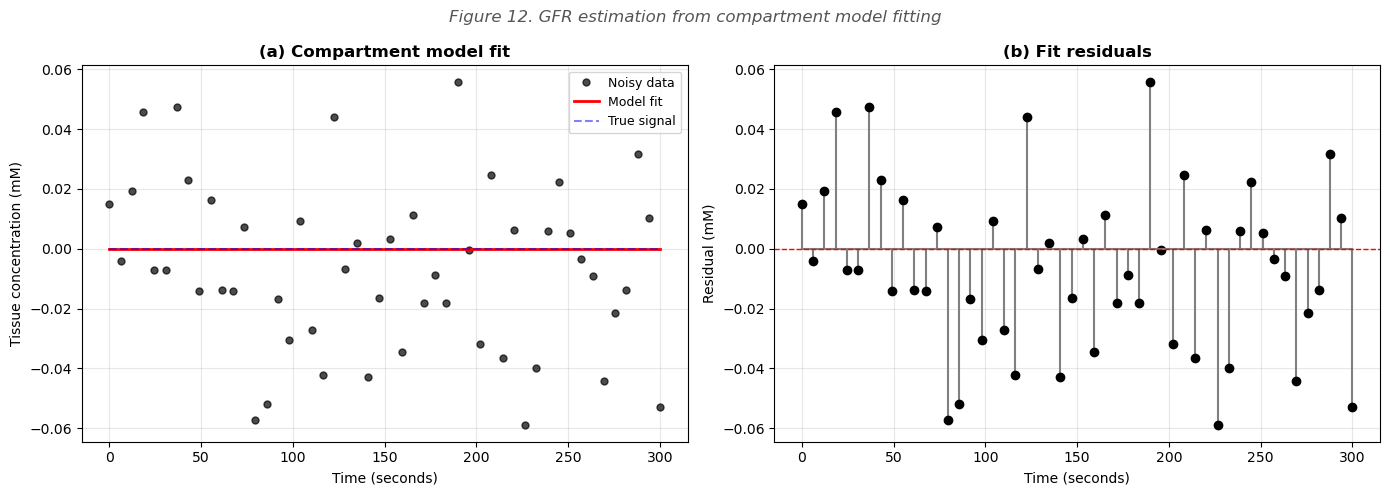

In [21]:
# GFR estimation via compartment model fitting

def tissue_model(t_data, Fp, GFR_d, vp, vt, Tt):
    y0 = [0.0, 0.0]
    sol = odeint(kidney_2compartment, y0, t_data, args=(Fp, GFR_d, vp, vt, Tt, arterial_input_function))
    return vp * sol[:, 0] + vt * sol[:, 1]

# Synthetic "measured" data with noise
np.random.seed(42)
t_meas = np.linspace(0, 5, 50)
C_true = tissue_model(t_meas, Fp=3.0, GFR_d=0.5, vp=0.15, vt=0.10, Tt=2.0)
noise_level = 0.03
C_noisy = C_true + noise_level * np.random.randn(len(t_meas))

try:
    popt, pcov = curve_fit(tissue_model, t_meas, C_noisy,
                           p0=[2.0, 0.3, 0.1, 0.1, 1.5],
                           bounds=([0.1, 0.01, 0.01, 0.01, 0.5], [10.0, 2.0, 0.5, 0.5, 5.0]),
                           maxfev=10000)
    pstd = np.sqrt(np.diag(pcov))
    param_names = ['Fp', 'GFR_d', 'vp', 'vt', 'Tt']
    true_values = [3.0, 0.5, 0.15, 0.10, 2.0]

    print('=' * 65)
    print('Compartment Model Fitting Results')
    print('=' * 65)
    print(f'{"Parameter":<12} {"True":>8} {"Estimated":>10} {"Std Error":>10} {"Error%":>8}')
    print('-' * 65)
    for name, true, est, se in zip(param_names, true_values, popt, pstd):
        err_pct = 100 * abs(est - true) / true
        print(f'  {name:<10} {true:>8.3f} {est:>10.3f} {se:>10.3f} {err_pct:>7.1f}%')

    V_kidney = 150
    skGFR_true = true_values[1] * V_kidney
    skGFR_est = popt[1] * V_kidney
    print(f'\n  Single-kidney GFR (V_kidney = {V_kidney} mL):')
    print(f'    True:      {skGFR_true:.1f} mL/min')
    print(f'    Estimated: {skGFR_est:.1f} mL/min')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    t_fine = np.linspace(0, 5, 500)
    C_fit_fine = tissue_model(t_fine, *popt)
    C_fit = tissue_model(t_meas, *popt)

    ax1.plot(t_meas*60, C_noisy, 'ko', markersize=5, label='Noisy data', alpha=0.7)
    ax1.plot(t_fine*60, C_fit_fine, 'r-', lw=2, label='Model fit')
    ax1.plot(t_meas*60, C_true, 'b--', lw=1.5, alpha=0.5, label='True signal')
    ax1.set_xlabel('Time (seconds)'); ax1.set_ylabel('Tissue concentration (mM)')
    ax1.set_title('(a) Compartment model fit', fontweight='bold')
    ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

    residuals = C_noisy - C_fit
    ax2.stem(t_meas*60, residuals, linefmt='gray', markerfmt='ko', basefmt='gray')
    ax2.axhline(0, color='red', ls='--', lw=1)
    ax2.set_xlabel('Time (seconds)'); ax2.set_ylabel('Residual (mM)')
    ax2.set_title('(b) Fit residuals', fontweight='bold')
    ax2.grid(True, alpha=0.3)

    plt.suptitle('Figure 12. GFR estimation from compartment model fitting', fontsize=12, fontstyle='italic', color='#555')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f'Curve fitting failed: {e}')

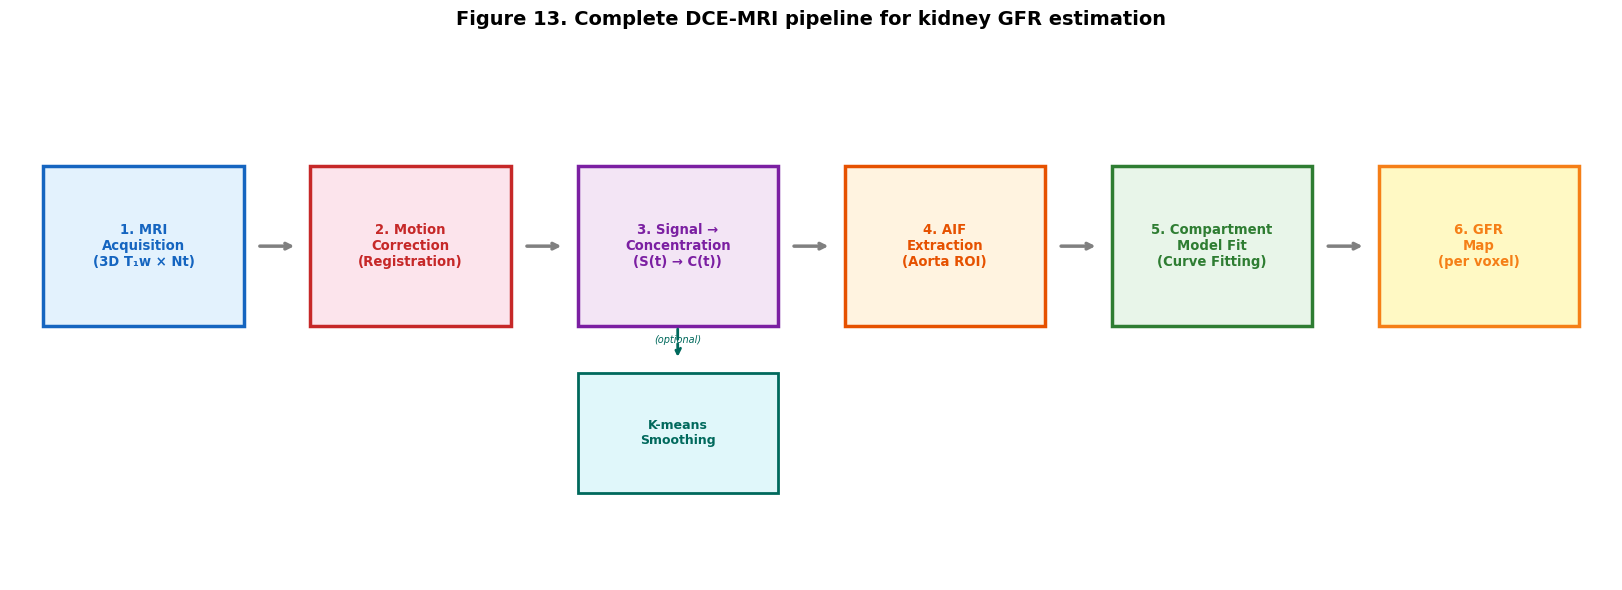

In [22]:
# Complete DCE-MRI GFR estimation pipeline
fig, ax = plt.subplots(1, 1, figsize=(18, 6))
ax.set_xlim(0, 24); ax.set_ylim(0, 8)
ax.set_aspect('equal')

steps = [
    (2, 5, '1. MRI\nAcquisition\n(3D T\u2081w \u00d7 Nt)', '#e3f2fd', '#1565c0'),
    (6, 5, '2. Motion\nCorrection\n(Registration)', '#fce4ec', '#c62828'),
    (10, 5, '3. Signal \u2192\nConcentration\n(S(t) \u2192 C(t))', '#f3e5f5', '#7b1fa2'),
    (14, 5, '4. AIF\nExtraction\n(Aorta ROI)', '#fff3e0', '#e65100'),
    (18, 5, '5. Compartment\nModel Fit\n(Curve Fitting)', '#e8f5e9', '#2e7d32'),
    (22, 5, '6. GFR\nMap\n(per voxel)', '#fff9c4', '#f57f17'),
]

for x, y, txt, fc, ec in steps:
    ax.add_patch(plt.Rectangle((x-1.5, y-1.2), 3, 2.4, facecolor=fc, edgecolor=ec, lw=2.5, zorder=2))
    ax.text(x, y, txt, ha='center', va='center', fontsize=9.5, fontweight='bold', color=ec, zorder=3)

for i in range(len(steps) - 1):
    ax.annotate('', xy=(steps[i+1][0]-1.7, steps[i+1][1]),
                xytext=(steps[i][0]+1.7, steps[i][1]),
                arrowprops=dict(arrowstyle='->', color='gray', lw=2.5))

ax.add_patch(plt.Rectangle((8.5, 1.3), 3, 1.8, facecolor='#e0f7fa', edgecolor='#00695c', lw=2, zorder=2))
ax.text(10, 2.2, 'K-means\nSmoothing', ha='center', va='center', fontsize=9, fontweight='bold', color='#00695c', zorder=3)
ax.annotate('', xy=(10, 3.3), xytext=(10, 3.8), arrowprops=dict(arrowstyle='->', color='#00695c', lw=2, ls='--'))
ax.text(10, 3.55, '(optional)', ha='center', fontsize=7, color='#00695c', style='italic')

ax.set_title('Figure 13. Complete DCE-MRI pipeline for kidney GFR estimation', fontsize=14, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

### DIY: Tracer Kinetics and Compartment Modeling

**Q8.** In the two-compartment kidney model, what happens to the tissue concentration curve $C_{tissue}(t)$ if GFR is very small (approaching zero)?

<details>
<summary>Click to reveal answer</summary>

If $GFR \to 0$ (no filtration), the tubular compartment receives no contrast agent. The tissue concentration becomes dominated by the **plasma compartment** alone:

$$C_{tissue}(t) \approx v_p \cdot C_p(t)$$

The curve would show a rapid wash-in and wash-out pattern (tracking the AIF), with no delayed component from tubular transit. The peak would be sharp and symmetric.

Clinically, this represents **end-stage renal disease** where the glomeruli are completely sclerosed and non-functional.

</details>

**Q9.** What is the **Arterial Input Function (AIF)** and why is it critical for quantitative DCE-MRI?

<details>
<summary>Click to reveal answer</summary>

The **AIF** ($C_a(t)$) is the concentration-time curve of the contrast agent in the arterial blood supplying the organ of interest. It is typically measured by placing a region of interest (ROI) in the **aorta** or **renal artery** on the DCE-MRI images.

The AIF is critical because:
1. It serves as the **input signal** to the compartment model
2. The tissue curve is a **convolution** of the AIF with the tissue impulse response
3. Errors in the AIF propagate directly into the estimated parameters — AIF accuracy is the **single largest source of error** in DCE-MRI quantification
4. The AIF shape varies between patients and injections

</details>

**Q10.** If a healthy kidney has a volume of 150 mL, a plasma flow of 3.0 mL/min/mL, and a filtration fraction of 20%, what is the estimated single-kidney GFR?

<details>
<summary>Click to reveal answer</summary>

$$GFR_{density} = FF \times F_p = 0.20 \times 3.0 = 0.60 \text{ mL/min/mL tissue}$$

$$\text{skGFR} = GFR_{density} \times V_{kidney} = 0.60 \times 150 = 90.0 \text{ mL/min}$$

This seems too high! A single kidney typically contributes about 45–60 mL/min. The discrepancy arises because not all of the 150 mL kidney volume is functional cortical parenchyma. Using a more realistic **functional cortical volume** of ~80 mL:

$$\text{skGFR} = 0.60 \times 80 = 48.0 \text{ mL/min}$$

This is physiologically reasonable. The lesson: **careful segmentation** of cortex vs. medulla is essential for accurate GFR estimation from DCE-MRI.

</details>

## 11. Putting It All Together: From Voxels to GFR Maps

In a full clinical DCE-MRI analysis, the steps would be:

1. **Motion correction** — register all time points to a reference volume
2. **Kidney segmentation** — identify cortex and medulla regions
3. **K-means smoothing** (optional) — reduce noise with K=64 prototypic time courses
4. **AIF extraction** — measure $C_a(t)$ from the aorta
5. **Voxel-wise or ROI-based model fitting** — fit the two-compartment model to each voxel/ROI
6. **Parameter maps** — display GFR, perfusion, and transit time as color maps overlaid on anatomy

Below, we demonstrate a simplified version: fitting the compartment model to the K-means cluster centroids to estimate mean GFR for each tissue cluster.

In [23]:
# Simplified GFR estimation per K-means cluster
t_meas_min = np.arange(nt) * 3.0 / 60.0

print('Fitting two-compartment model to K=8 cluster centroids...\n')
print(f'{"Cluster":>8} {"Fp":>8} {"GFR_d":>8} {"vp":>8} {"vt":>8} {"Tt":>8} {"skGFR*":>10}')
print('-' * 65)

cluster_params = []
V_kidney_cortex = 80

for k in range(K):
    centroid = centroids_original[k]
    baseline_val = np.mean(centroid[:3])
    enhancement = centroid - baseline_val
    C_approx = enhancement / (np.max(enhancement) + 1e-10) * 0.5

    try:
        popt, pcov = curve_fit(tissue_model, t_meas_min[:len(C_approx)], C_approx,
                               p0=[2.0, 0.3, 0.1, 0.05, 1.5],
                               bounds=([0.01, 0.001, 0.001, 0.001, 0.1], [10.0, 2.0, 0.5, 0.5, 10.0]),
                               maxfev=5000)
        Fp_est, GFR_est, vp_est, vt_est, Tt_est = popt
        skGFR = GFR_est * V_kidney_cortex
        print(f'  {k:>5d} {Fp_est:>8.2f} {GFR_est:>8.3f} {vp_est:>8.3f} '
              f'{vt_est:>8.3f} {Tt_est:>8.2f} {skGFR:>9.1f}')
        cluster_params.append({'cluster': k, 'Fp': Fp_est, 'GFR_d': GFR_est,
                               'vp': vp_est, 'vt': vt_est, 'Tt': Tt_est, 'skGFR': skGFR})
    except Exception as e:
        print(f'  {k:>5d}  (fitting failed: {str(e)[:40]})')
        cluster_params.append({'cluster': k, 'Fp': np.nan, 'GFR_d': np.nan,
                               'vp': np.nan, 'vt': np.nan, 'Tt': np.nan, 'skGFR': np.nan})

print(f'\n* skGFR = GFR_density x {V_kidney_cortex} mL (assumed cortical volume)')
print('  Note: These are illustrative values; accurate GFR requires proper')
print('  signal-to-concentration conversion and AIF measurement.')

Fitting two-compartment model to K=8 cluster centroids...

 Cluster       Fp    GFR_d       vp       vt       Tt     skGFR*
-----------------------------------------------------------------
      0     2.00    0.300    0.100    0.050     1.50      24.0
      1     2.00    0.300    0.100    0.050     1.50      24.0
      2     2.00    0.300    0.100    0.050     1.50      24.0
      3     2.00    0.300    0.100    0.050     1.50      24.0
      4     2.00    0.300    0.100    0.050     1.50      24.0
      5     2.00    0.300    0.100    0.050     1.50      24.0
      6     2.00    0.300    0.100    0.050     1.50      24.0
      7     2.00    0.300    0.100    0.050     1.50      24.0

* skGFR = GFR_density x 80 mL (assumed cortical volume)
  Note: These are illustrative values; accurate GFR requires proper
  signal-to-concentration conversion and AIF measurement.


## 12. Summary and Going Deeper

### What we covered

This notebook explored the full pipeline of **DCE-MRI-based kidney GFR estimation** as a case study in computational medicine:

| Topic | Key concepts |
|-------|--------------|
| **DCE-MRI basics** | Gd contrast injection, T\u2081 enhancement, 4D data, signal-to-concentration conversion |
| **Definitions** | GFR, AIF, compartment models, tracer kinetics, impulse residue function |
| **Historical context** | From indicator dilution theory (1927) to modern AI-assisted analysis (2020s) |
| **Data exploration** | Loading NIfTI files, temporal montage, ROI-based time courses |
| **Motion correction** | Respiratory motion, rigid/deformable registration, center-of-mass tracking |
| **K-means clustering** | Voxel time courses as feature vectors in $\mathbf{R}^{N_t}$, tissue segmentation |
| **K-means smoothing** | 64 prototypic time courses, adaptive noise reduction |
| **Compartment modeling** | Two-compartment (plasma + tubular) ODE model, GFR as a model parameter |
| **GFR estimation** | Curve fitting, parameter maps, single-kidney GFR |

### Extensions and advanced topics

1. **Proper AIF extraction**: Automated detection of the aorta, partial volume correction, T2* correction at high concentrations
2. **Non-linear signal-to-concentration conversion**: Using the full SPGR signal equation with pre-contrast T\u2081 mapping
3. **Bayesian inference**: Incorporating prior physiological knowledge into parameter estimation to improve robustness
4. **Deep learning approaches**: Neural networks for automated kidney segmentation, motion correction, and parameter estimation
5. **Multi-site standardization**: The [PARENCHIMA](https://renalmri.org) COST Action and [UKRIN-MAPS](https://www.nottingham.ac.uk/research/groups/spmic/research/uk-renal-imaging-network/ukrin-maps.aspx) project for standardizing renal MRI protocols
6. **Radiomics and texture analysis**: Extracting higher-order features from DCE-MRI parameter maps for phenotyping kidney disease
7. **Diffusion-weighted MRI (DWI)**: Complementary technique for assessing renal microstructure without contrast agents

### Key references

1. **Tofts, P.S. & Kermode, A.G.** (1991). Measurement of the blood-brain barrier permeability and leakage space using dynamic MR imaging. *Magn. Reson. Med.* 17:357–367.
2. **Sourbron, S.P., Michaely, H.J., Reiser, M.F. & Schoenberg, S.O.** (2008). MRI-measurement of perfusion and glomerular filtration in the human kidney with a separable compartment model. *Invest. Radiol.* 43:40–48.
3. **Hodneland, E., Hanson, E.A., Lundervold, A., Modersitzki, J., Eikefjord, E. & Munthe-Kaas, A.Z.** (2014). Segmentation-driven image registration — application to 4D DCE-MRI recordings of the moving kidneys. *IEEE Trans. Image Process.* 23:2392–2404.
4. **Eikefjord, E., Andersen, E., Hodneland, E., Zöllner, F., Lundervold, A., Svarstad, E. & Rørvik, J.** (2015). Use of 3D DCE-MRI for the estimation of renal perfusion and glomerular filtration rate. *AJR Am. J. Roentgenol.* 204:W273–W281.
5. **Annet, L., Hermoye, L., Peeters, F., Jamar, F., Dehoux, J.P. & Van Beers, B.E.** (2004). Glomerular filtration rate: assessment with dynamic contrast-enhanced MRI and a cortical-compartment model in the rabbit kidney. *J. Magn. Reson. Imaging* 20:843–849.
6. **PARENCHIMA Consensus Papers** (2020). Technical recommendations for clinical renal MRI. *MAGMA* 33:131–195.
7. **Layton, A.T. & Edwards, A.** (2014). *Mathematical Modeling in Renal Physiology*. Springer.

### Software tools

- **MRTOOL** / **PMI** — MATLAB-based tools for DCE-MRI analysis (Sourbron group)
- **DCE@urLAB** — Open-source Python/MATLAB package for DCE-MRI pharmacokinetic modeling
- **ROCKETSHIP** — ImageJ/MATLAB plugin for DCE-MRI analysis
- **nibabel** + **scipy** + **scikit-learn** — The Python ecosystem used in this notebook

## 13. DIY Exercises: Explore Further

### Exercise 1: Vary K in K-means Clustering

Run the K-means clustering with different values of K (e.g., K = 4, 16, 32, 64, 128). How does the cluster map change? How does it affect the smoothed time courses?

<details>
<summary>Click for starter code</summary>

```python
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
K_values = [4, 8, 16, 32, 64, 128]

for idx, K_val in enumerate(K_values):
    ax = axes.flat[idx]
    km = KMeans(n_clusters=K_val, n_init=5, random_state=42, max_iter=200)
    labels_k = np.full(nx * ny, -1, dtype=int)
    labels_k[mask_foreground] = km.fit_predict(X_norm[mask_foreground])
    lmap = labels_k.reshape(nx, ny).astype(float)
    lmap[labels_k.reshape(nx, ny) == -1] = np.nan
    ax.imshow(lmap.T, cmap='tab20', origin='upper', aspect='auto')
    ax.set_title(f'K = {K_val}', fontweight='bold')
    ax.axis('off')
plt.suptitle('K-means clustering with different K values', fontsize=14)
plt.tight_layout()
plt.show()
```

</details>

<details>
<summary>Click for what you should observe</summary>

- **K=4**: Very coarse segmentation — likely distinguishes only background, cortex, medulla, and vessels
- **K=8–16**: Good tissue differentiation, clear cortex-medulla separation
- **K=32–64**: Fine-grained segmentation, captures gradients within cortex/medulla
- **K=128**: Very fine, approaching individual voxel level — limited additional benefit but less smoothing

The **elbow method** (plotting total within-cluster variance vs. K) can help choose an appropriate K.

</details>

### Exercise 2: Explore Different Slices

The kidney anatomy varies dramatically across slices. Apply the analysis to different slices (not just the middle one) and compare the results.

<details>
<summary>Click for starter code</summary>

```python
slices_to_show = [n_z // 4, n_z // 2, 3 * n_z // 4]
fig, axes = plt.subplots(len(slices_to_show), 3, figsize=(15, 5 * len(slices_to_show)))

for row, sl in enumerate(slices_to_show):
    sl_data = data[:, :, sl, :]
    sl_X = sl_data.reshape(-1, nt)
    sl_mask = np.mean(sl_X, axis=1) > np.percentile(np.mean(sl_X, axis=1), 25)

    axes[row, 0].imshow(sl_data[:, :, 0].T, cmap='gray', origin='upper', aspect='auto')
    axes[row, 0].set_title(f'Slice {sl}: Baseline', fontweight='bold')

    t_peak = min(10, nt - 1)
    axes[row, 1].imshow(sl_data[:, :, t_peak].T, cmap='gray', origin='upper', aspect='auto')
    axes[row, 1].set_title(f'Slice {sl}: t={t_peak}', fontweight='bold')

    km_sl = KMeans(n_clusters=8, n_init=5, random_state=42)
    labels_sl = np.full(nx * ny, -1, dtype=int)
    sl_X_norm = np.zeros_like(sl_X, dtype=float)
    sl_X_norm[sl_mask] = sl_X[sl_mask] - sl_X[sl_mask].mean(axis=1, keepdims=True)
    std_sl = sl_X[sl_mask].std(axis=1, keepdims=True)
    std_sl[std_sl == 0] = 1
    sl_X_norm[sl_mask] /= std_sl
    labels_sl[sl_mask] = km_sl.fit_predict(sl_X_norm[sl_mask])
    lmap_sl = labels_sl.reshape(nx, ny).astype(float)
    lmap_sl[labels_sl.reshape(nx, ny) == -1] = np.nan
    axes[row, 2].imshow(lmap_sl.T, cmap='tab10', origin='upper', aspect='auto')
    axes[row, 2].set_title(f'Slice {sl}: K-means (K=8)', fontweight='bold')

    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
plt.show()
```

</details>

### Exercise 3: Sensitivity Analysis of Compartment Model

Explore how the compartment model output changes when you vary individual parameters. This helps build intuition for what the model "sees" in the data.

<details>
<summary>Click for starter code</summary>

```python
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
t_sim = np.linspace(0, 5, 300)

baseline_params = {'Fp': 3.0, 'GFR_d': 0.5, 'vp': 0.15, 'vt': 0.10, 'Tt': 2.0}
vary_params = {
    'Fp': [1.0, 2.0, 3.0, 4.0, 5.0],
    'GFR_d': [0.1, 0.3, 0.5, 0.7, 1.0],
    'vp': [0.05, 0.10, 0.15, 0.20, 0.30],
    'Tt': [0.5, 1.0, 2.0, 3.0, 5.0]
}

for ax, (param_name, values) in zip(axes.flat, vary_params.items()):
    for val in values:
        params = baseline_params.copy()
        params[param_name] = val
        sol = odeint(kidney_2compartment, [0, 0], t_sim,
                     args=(params['Fp'], params['GFR_d'], params['vp'],
                           params['vt'], params['Tt'], arterial_input_function))
        C = params['vp'] * sol[:, 0] + params['vt'] * sol[:, 1]
        ax.plot(t_sim * 60, C, lw=2, label=f'{param_name}={val}')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('C_tissue (mM)')
    ax.set_title(f'Varying {param_name}', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
```

</details>

---

**Notebook summary**: This notebook explored **DCE-MRI of the kidney** as a computational medicine approach to non-invasive GFR estimation. We covered the physics of DCE-MRI acquisition, the mathematics of tracer kinetic compartment models, practical aspects of motion correction and K-means clustering/smoothing, and the clinical significance of image-based kidney function assessment. The notebook builds on [06-kidney-filtration.ipynb](./06-kidney-filtration.ipynb) (physiology and mathematical modeling of GFR) by adding the imaging dimension — turning abstract filtration rates into spatially-resolved, patient-specific functional maps.

*Created for BMED365 — Computational Medicine, University of Bergen, 2026.*

**See also:**
- [functional-kidney-imaging](https://github.com/arvidl/functional-kidney-imaging) — ESMRMB 2016 teaching materials on renal perfusion and filtration with MRI
- [BMED360-2021 Lab5-DCE-MRI](https://github.com/computational-medicine/BMED360-2021/tree/main/Lab5-DCE-MRI) — Original source notebook
- [PARENCHIMA](https://renalmri.org) — European network for standardization of renal MRI